# Leduc Poker — CFR vs Deep Self-Play

Companion notebook to the thesis *Approximating Nash Equilibria in Imperfect-Information
Games: A Comparison of CFR and Deep Self-Play on Leduc Poker* (Bocconi BAI). The notebook
is the source of every number, curve, and table reported in the paper — see `PLAN.md` for
the full specification.

**Status:** complete — §0-§8 (setup, game, CFR/CFR+, Deep CFR, NFSP, RMPG, PPO, head-to-head,
3-player extension), §9 (robustness / sensitivity), §9.4 (mean reward vs CFR), §10 (aggregate
and export). Supplementary strategy-interpretation analyses (behavioural fingerprints, the
RMPG-entropy and NFSP-η experiments) live alongside as scripts pending write-up.

## §0 Setup

Imports, device detection (MPS / CUDA / CPU — Leduc is tiny so CPU is fine; MPS exists
for later deep agents on the M5), seeds, and a single config cell that controls every
experiment. Scaling a run up or down is a one-line change in `CONFIG`.


In [1]:
import json
import os
import pickle
import random
import time
from dataclasses import dataclass, field, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from tqdm.auto import tqdm

import pyspiel
from open_spiel.python import policy as policy_lib
from open_spiel.python import rl_environment
from open_spiel.python.algorithms import cfr, exploitability, expected_game_score
from open_spiel.python.pytorch import deep_cfr, nfsp, policy_gradient, ppo

print("torch       :", torch.__version__)
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("open_spiel  :", pyspiel.__doc__.splitlines()[0] if pyspiel.__doc__ else "(no docstring)")

Optional module pokerkit_wrapper was not importable: No module named 'pokerkit'
torch       : 2.8.0
numpy       : 2.4.6
pandas      : 3.0.3
open_spiel  : Open Spiel


/Users/dk/Developer/Leduc/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def pick_device() -> torch.device:
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = pick_device()
print("torch device:", DEVICE)


torch device: mps


In [3]:
PROJECT_ROOT = Path.cwd()
DATA_DIR        = PROJECT_ROOT / "data"
CHECKPOINTS_DIR = DATA_DIR / "checkpoints"
RESULTS_DIR     = DATA_DIR / "results"
FIGURES_DIR     = DATA_DIR / "figures"
for d in (CHECKPOINTS_DIR, RESULTS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)


@dataclass
class Config:
    # Game.
    game_name: str = "leduc_poker"

    # CFR / CFR+ (§2). Leduc converges fast; 2000 iters is plenty to land
    # below 1e-3 exploitability with CFR+ and still see CFR's slower descent.
    cfr_iterations: int = 2000
    cfr_eval_every: int = 25

    # Deep CFR (§3). Brown et al. (2019) — neural approximation of CFR. Networks are
    # kept Leduc-small (PLAN §6). `deepcfr_eval_every` is the chunk size: we call the
    # solver's solve() this many iterations at a time so we can evaluate exploitability
    # of the strategy network along the way (solve() otherwise reports nothing per
    # iteration). 150 iters lands exploitability around ~0.2-0.3 chips/hand in ~80 s on
    # CPU — a clear descent that plateaus well above the tabular floor, as expected for
    # a sampled, function-approximated method. One-line scalable.
    deepcfr_iterations: int = 150
    deepcfr_eval_every: int = 2
    deepcfr_num_traversals: int = 40
    deepcfr_learning_rate: float = 1e-3
    deepcfr_batch_size: int = 2048
    deepcfr_train_steps: int = 400
    deepcfr_memory_capacity: int = int(1e6)
    deepcfr_policy_layers: tuple[int, ...] = (64, 64)
    deepcfr_advantage_layers: tuple[int, ...] = (64, 64)
    # Tiny nets + tiny batches: CPU beats MPS/CUDA here (transfer overhead dominates).
    deepcfr_device: str = "cpu"

    # NFSP (§4). Heinrich & Silver (2016) — neural fictitious self-play. Two RL agents
    # play each other; each mixes a DQN best-response (RL net) with a supervised average
    # policy (SL net) trained on a reservoir of its own past best-response moves. The
    # *average* (SL) policy is the one that converges, so it is what we evaluate and save.
    # Defaults follow OpenSpiel's leduc NFSP example. NFSP converges slowly on Leduc:
    # ~1M episodes (~8 min CPU) shows a clear monotone descent but stays above the tabular
    # floor; the known sub-0.1 floor needs several million episodes. One-line scalable.
    nfsp_train_episodes: int = 1_000_000
    nfsp_eval_every: int = 5_000
    nfsp_hidden_layers: tuple[int, ...] = (128,)
    nfsp_replay_buffer_capacity: int = int(2e5)
    nfsp_reservoir_buffer_capacity: int = int(2e6)
    nfsp_min_buffer_size_to_learn: int = 1000
    nfsp_anticipatory_param: float = 0.1     # P(play RL best response) per episode
    nfsp_batch_size: int = 128
    nfsp_learn_every: int = 64
    nfsp_rl_learning_rate: float = 0.01
    nfsp_sl_learning_rate: float = 0.01
    nfsp_optimizer: str = "sgd"
    nfsp_loss: str = "mse"
    nfsp_update_target_network_every: int = 19200
    nfsp_discount_factor: float = 1.0
    nfsp_epsilon_start: float = 0.06
    nfsp_epsilon_end: float = 0.001

    # Policy-gradient self-play (§5). Srinivasan et al. (2018) — regret-based actor-critic.
    # We use RMPG (loss "rm"), the regret-matching policy-gradient variant suggested in
    # PLAN §6. Unlike NFSP there is no separate averaging network: the *current* policy net
    # is the iterate driven toward equilibrium, so it is what we evaluate and save. Same
    # rl_environment self-play loop as NFSP.
    #
    # Tuning notes (from a sweep — see PLAN §5/§11 "verify, don't assume"): OpenSpiel's
    # default (sgd, large batch) barely moves on Leduc, while aggressive Adam settings drive
    # exploitability down fast but then DIVERGE past ~0.5M episodes (the current policy
    # overshoots — no averaging to stabilize it). Low pi-LR + entropy regularization +
    # gradient clipping keeps it bounded: this config descends to ~0.9 and oscillates in
    # ~[0.87, 1.27] over 1M episodes (~3 min CPU) without blowing up. It stays noisy and far
    # above NFSP / tabular CFR — the expected, honest result. One-line scalable.
    pg_loss: str = "rm"                      # rm = RMPG; also rpg / qpg / a2c available
    pg_train_episodes: int = 1_000_000
    pg_eval_every: int = 5_000
    pg_hidden_layers: tuple[int, ...] = (128,)
    pg_batch_size: int = 16                  # episodes gathered before each critic update
    pg_critic_learning_rate: float = 0.01
    pg_pi_learning_rate: float = 0.001
    pg_entropy_cost: float = 0.005
    pg_num_critic_before_pi: int = 8
    pg_optimizer: str = "adam"
    pg_max_global_gradient_norm: float = 5.0  # clip — essential for RMPG stability on Leduc

    # PPO self-play (§6) — the NEGATIVE baseline. Schulman et al. (2017). OpenSpiel's PPO is
    # CleanRL-adapted and single-agent (PLAN §5 caveat), so we wrap it: one PPO learner plays
    # a single-agent MDP in which the opponent seat is auto-played by the learner's *current*
    # policy (naive self-play), with the learner's seat randomized each episode. We evaluate
    # the current policy's exploitability — there is no equilibrium machinery, so it is
    # EXPECTED to oscillate and never converge to 0 (it best-responds to a moving target).
    # ~3000 updates × 128 steps ≈ 384k learner decisions (~2 min CPU) shows the cycling.
    ppo_total_steps: int = 384_000           # learner decisions (env steps)
    ppo_steps_per_batch: int = 128
    ppo_eval_every_updates: int = 15
    ppo_num_minibatches: int = 4
    ppo_update_epochs: int = 4
    ppo_learning_rate: float = 2.5e-4
    ppo_gamma: float = 0.99
    ppo_gae_lambda: float = 0.95
    ppo_clip_coef: float = 0.2
    ppo_entropy_coef: float = 0.01
    ppo_value_coef: float = 0.5
    ppo_max_grad_norm: float = 0.5

    # 3-player Leduc extension (§8) — the key qualitative experiment (PLAN §3/§8). With >2
    # players Leduc is no longer 2p-zero-sum: Nash is not unique and self-play has no
    # convergence guarantee. We measure NashConv (exploitability is 2-player-only). Each eval
    # is expensive (~25 s: 25,800 info sets x 3 best responses), so we evaluate at a few
    # milestones and keep budgets modest — enough to show that CFR reduces NashConv well while
    # the deep self-play methods plateau far higher. That gap IS the finding.
    p3_players: int = 3
    p3_cfr_iterations: int = 50
    p3_cfr_eval_iters: tuple[int, ...] = (1, 3, 5, 8, 11, 14, 17, 20, 23, 26, 29, 32, 35, 38, 41, 44, 47, 50)
    p3_nfsp_episodes: int = 200_000
    p3_pg_episodes: int = 200_000
    p3_ppo_steps: int = 150_000
    p3_deep_eval_points: int = 20          # NashConv evals spread across each deep run

    # §9 robustness / sensitivity (PLAN §7/§9). Reduced budgets vs §3-§6 so 5-seed bands plus a
    # small sweep stay affordable — the point is cross-seed VARIANCE and reproducibility, which
    # show well before full convergence. Everything is 2-player, so exploitability evals are
    # cheap and only training costs time. The multi-seed runs reuse the §3-§6 train_* functions
    # with these budgets swapped in via dataclasses.replace.
    robustness_seeds: tuple[int, ...] = (0, 1, 2, 3, 4)
    r9_deepcfr_iterations: int = 80
    r9_deepcfr_eval_every: int = 1
    r9_nfsp_episodes: int = 150_000
    r9_nfsp_eval_every: int = 1_500
    r9_pg_episodes: int = 150_000
    r9_pg_eval_every: int = 1_500
    r9_ppo_steps: int = 120_000
    r9_ppo_eval_every_updates: int = 8
    # Sensitivity sweep: NFSP anticipatory parameter eta (the canonical NFSP knob; 0.1 default).
    r9_sweep_etas: tuple[float, ...] = (0.05, 0.1, 0.3, 0.5)
    r9_sweep_seeds: tuple[int, ...] = (0, 1)

    # §9.4 mean-reward-vs-CFR benchmark (Srinivasan et al. 2018 style). Fixed CFR opponents at
    # several iteration counts; we track each deep method's EXACT seat-averaged reward against
    # them over training. 2-player only (3-player CFR is ~10 s/iter, infeasible to CFR500+).
    # Evals are exact tree expectations and cheap, so only training costs time.
    mr_cfr_snapshots: tuple[int, ...] = (100, 500, 1000, 2000)
    mr_nfsp_episodes: int = 1_000_000
    mr_pg_episodes: int = 1_000_000
    mr_ppo_steps: int = 384_000
    mr_deepcfr_iterations: int = 150
    mr_eval_points: int = 20

    # Seeds. Tabular CFR is deterministic so one seed suffices; the deep methods
    # sweep over this list for the robustness study — see PLAN §7 / §9. Each deep
    # section trains a single seed for its own checkpoint + curve; §9 does the band.
    seeds: tuple[int, ...] = (0, 1, 2, 3, 4)

    # Paths (kept here so every experiment writes under data/ consistently).
    checkpoints_dir: Path = field(default_factory=lambda: CHECKPOINTS_DIR)
    results_dir:     Path = field(default_factory=lambda: RESULTS_DIR)
    figures_dir:     Path = field(default_factory=lambda: FIGURES_DIR)


CONFIG = Config()
print(CONFIG)

Config(game_name='leduc_poker', cfr_iterations=2000, cfr_eval_every=25, deepcfr_iterations=150, deepcfr_eval_every=2, deepcfr_num_traversals=40, deepcfr_learning_rate=0.001, deepcfr_batch_size=2048, deepcfr_train_steps=400, deepcfr_memory_capacity=1000000, deepcfr_policy_layers=(64, 64), deepcfr_advantage_layers=(64, 64), deepcfr_device='cpu', nfsp_train_episodes=1000000, nfsp_eval_every=5000, nfsp_hidden_layers=(128,), nfsp_replay_buffer_capacity=200000, nfsp_reservoir_buffer_capacity=2000000, nfsp_min_buffer_size_to_learn=1000, nfsp_anticipatory_param=0.1, nfsp_batch_size=128, nfsp_learn_every=64, nfsp_rl_learning_rate=0.01, nfsp_sl_learning_rate=0.01, nfsp_optimizer='sgd', nfsp_loss='mse', nfsp_update_target_network_every=19200, nfsp_discount_factor=1.0, nfsp_epsilon_start=0.06, nfsp_epsilon_end=0.001, pg_loss='rm', pg_train_episodes=1000000, pg_eval_every=5000, pg_hidden_layers=(128,), pg_batch_size=16, pg_critic_learning_rate=0.01, pg_pi_learning_rate=0.001, pg_entropy_cost=0.005,

In [4]:
def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


set_global_seed(CONFIG.seeds[0])


### §0.1 API check (PLAN §5)

Library APIs drift between OpenSpiel releases. This cell records what the *installed*
version actually exposes for the calls we depend on, so future-me / a reader can spot
breakage at a glance instead of debugging blind.


In [5]:
import inspect

_game = pyspiel.load_game(CONFIG.game_name)
_api = {
    "open_spiel_pkg":              __import__("open_spiel").__file__,
    "pyspiel.load_game":           "pyspiel.load_game('leduc_poker') -> Game",
    "num_players":                 _game.num_players(),
    "num_distinct_actions":        _game.num_distinct_actions(),
    "info_state_tensor_size":      _game.information_state_tensor_size(),
    "max_chance_outcomes":         _game.max_chance_outcomes(),
    "exploitability.exploitability": str(inspect.signature(exploitability.exploitability)),
    "exploitability.nash_conv":      str(inspect.signature(exploitability.nash_conv)),
    "cfr.CFRSolver.__init__":      str(inspect.signature(cfr.CFRSolver.__init__)),
    "cfr.CFRPlusSolver.__init__":  str(inspect.signature(cfr.CFRPlusSolver.__init__)),
}
for k, v in _api.items():
    print(f"{k:35s} {v}")


open_spiel_pkg                      /Users/dk/Developer/Leduc/.venv/lib/python3.13/site-packages/open_spiel/__init__.py
pyspiel.load_game                   pyspiel.load_game('leduc_poker') -> Game
num_players                         2
num_distinct_actions                3
info_state_tensor_size              30
max_chance_outcomes                 6
exploitability.exploitability       (game, policy)
exploitability.nash_conv            (game, policy, return_only_nash_conv=True, use_cpp_br=False)
cfr.CFRSolver.__init__              (self, game)
cfr.CFRPlusSolver.__init__          (self, game)


## §1 The game & the ruler

**Metric (the ruler).** For a joint policy $\sigma=(\sigma_1,\dots,\sigma_n)$, player $i$'s *best-response value* is $b_i(\sigma_{-i})=\max_{\sigma_i'} u_i(\sigma_i',\sigma_{-i})$. **NashConv**$(\sigma)=\sum_i\big(b_i(\sigma_{-i})-u_i(\sigma)\big)\ge 0$ is the total incentive of all players to deviate; it equals $0$ iff $\sigma$ is a Nash equilibrium. For two-player zero-sum games, **exploitability**$(\sigma)=\tfrac12\,\mathrm{NashConv}(\sigma)$ — the chips/hand a worst-case adversary beats $\sigma$ by. OpenSpiel computes a best response exactly over the game tree, so both quantities are exact (no sampling noise).

Load Leduc, print its facts, and sanity-check the exploitability function on the
uniform-random policy. Exploitability of uniform-random play on 2-player Leduc is
≈ 2 chips/hand — a finite, positive number. Getting a sensible value here confirms
the evaluation pipeline before we trust it on trained policies.


In [6]:
game = pyspiel.load_game(CONFIG.game_name)

print(f"game                     : {CONFIG.game_name}")
print(f"num_players              : {game.num_players()}")
print(f"num_distinct_actions     : {game.num_distinct_actions()}  (fold / call / raise)")
print(f"info_state_tensor_size   : {game.information_state_tensor_size()}")
print(f"max_chance_outcomes      : {game.max_chance_outcomes()}  (6-card deck)")
print(f"max_utility              : {game.max_utility()}")
print(f"min_utility              : {game.min_utility()}")


game                     : leduc_poker
num_players              : 2
num_distinct_actions     : 3  (fold / call / raise)
info_state_tensor_size   : 30
max_chance_outcomes      : 6  (6-card deck)
max_utility              : 13.0
min_utility              : -13.0


In [7]:
# Number of distinct information sets — the size of the tabular policy table.
uniform = policy_lib.UniformRandomPolicy(game)
tabular_uniform = policy_lib.tabular_policy_from_callable(game, uniform.action_probabilities)
n_infosets = len(tabular_uniform.state_lookup)
print(f"distinct information sets: {n_infosets}")


distinct information sets: 936


In [8]:
expl_uniform = exploitability.exploitability(game, tabular_uniform)
nash_uniform = exploitability.nash_conv(game, tabular_uniform)
print(f"exploitability (uniform) : {expl_uniform:.6f}  chips/hand")
print(f"NashConv       (uniform) : {nash_uniform:.6f}  chips/hand")
print()
print("Sanity check: both numbers should be positive and on the order of ~1 chip/hand.")
print("A trained equilibrium policy in §2 should drive exploitability orders of magnitude lower.")


exploitability (uniform) : 2.373611  chips/hand
NashConv       (uniform) : 4.747222  chips/hand

Sanity check: both numbers should be positive and on the order of ~1 chip/hand.
A trained equilibrium policy in §2 should drive exploitability orders of magnitude lower.


## §2 CFR and CFR+ baseline

**Theory.** CFR minimizes *counterfactual regret* locally at each information set $I$. Let $v_i(\sigma,I)$ be player $i$'s counterfactual value at $I$ (expected payoff weighting only the opponents'/chance reach to $I$). The instantaneous regret of action $a$ at iteration $t$ is $r^t(I,a)=v_i(\sigma^t_{I\to a},I)-v_i(\sigma^t,I)$, with cumulative regret $R^T(I,a)=\sum_{t\le T}r^t(I,a)$. The next policy is **regret matching**,
$$\sigma^{T+1}(I,a)=\frac{R^{T,+}(I,a)}{\sum_b R^{T,+}(I,b)},\qquad x^+=\max(x,0)$$
(uniform if all regrets are $\le 0$). The total regret is bounded by $O(\sqrt T)$, so the **average** policy $\bar\sigma^T$ — not the current iterate — converges to a Nash equilibrium with exploitability $O(1/\sqrt T)$. **CFR+** replaces $R^{T,+}$ with *regret-matching$^+$* (cumulative regrets floored at $0$ each iteration) and uses linear averaging, giving the much faster $\approx O(1/T)$ decay.

Counterfactual Regret Minimization (Zinkevich et al., 2007) and its CFR+ variant
(Tammelin, 2014) are the reference equilibrium-finders for two-player zero-sum
imperfect-information games. We train both with OpenSpiel's tabular implementations,
log exploitability of the *average policy* (the iterate that converges, not the
current strategy), and persist the trained average policy as the ground-truth
equilibrium used for evaluating every deep method in §3–§6.

**Expectation.** CFR's exploitability decays as O(1/√T) — slow but monotone in
expectation. CFR+ decays roughly O(1/T) on Leduc-scale games — visibly faster on
the same iteration budget. Both should land near 1e-3 chips/hand by 2 000 iters.


In [9]:
def train_cfr(
    solver_cls,
    game,
    *,
    iterations: int,
    eval_every: int,
    label: str,
    seed: int = 0,
) -> tuple[pd.DataFrame, "policy_lib.TabularPolicy"]:
    '''Train a tabular CFR-family solver and log exploitability over time.

    Returns a tidy DataFrame matching the schema in PLAN §9 plus the final average policy.
    Tabular CFR is deterministic; `seed` is only stored alongside the row for schema
    parity with the deep methods.
    '''
    set_global_seed(seed)
    solver = solver_cls(game)

    rows: list[dict] = []
    t0 = time.perf_counter()
    for it in tqdm(range(1, iterations + 1), desc=label, leave=False):
        solver.evaluate_and_update_policy()
        if it % eval_every == 0 or it == 1 or it == iterations:
            avg_policy = solver.average_policy()
            expl = exploitability.exploitability(game, avg_policy)
            rows.append({
                "method":         label,
                "seed":           seed,
                "iteration":      it,
                "episodes":       np.nan,                  # not episode-based
                "wall_clock_s":   time.perf_counter() - t0,
                "exploitability": expl,
            })
    df = pd.DataFrame(rows)
    return df, solver.average_policy()


In [10]:
df_cfr, avg_cfr = train_cfr(
    cfr.CFRSolver,
    game,
    iterations=CONFIG.cfr_iterations,
    eval_every=CONFIG.cfr_eval_every,
    label="CFR",
)
df_cfr.tail(3)


,method,seed,iteration,episodes,wall_clock_s,exploitability
78,CFR,0,1950,NaN,86.271901,0.007222
79,CFR,0,1975,NaN,87.366052,0.006880
80,CFR,0,2000,NaN,88.490473,0.006849


In [11]:
df_cfrp, avg_cfrp = train_cfr(
    cfr.CFRPlusSolver,
    game,
    iterations=CONFIG.cfr_iterations,
    eval_every=CONFIG.cfr_eval_every,
    label="CFR+",
)
df_cfrp.tail(3)


,method,seed,iteration,episodes,wall_clock_s,exploitability
78,CFR+,0,1950,NaN,96.808419,0.000093
79,CFR+,0,1975,NaN,98.039977,0.000085
80,CFR+,0,2000,NaN,99.271851,0.000085


In [12]:
# Persist the per-iteration log so §10 can rebuild the figure without retraining.
df_cfr_all = pd.concat([df_cfr, df_cfrp], ignore_index=True)
csv_path = CONFIG.results_dir / "cfr_baseline.csv"
df_cfr_all.to_csv(csv_path, index=False)
print(f"wrote {csv_path.relative_to(PROJECT_ROOT)}  ({len(df_cfr_all)} rows)")


wrote data/results/cfr_baseline.csv  (162 rows)


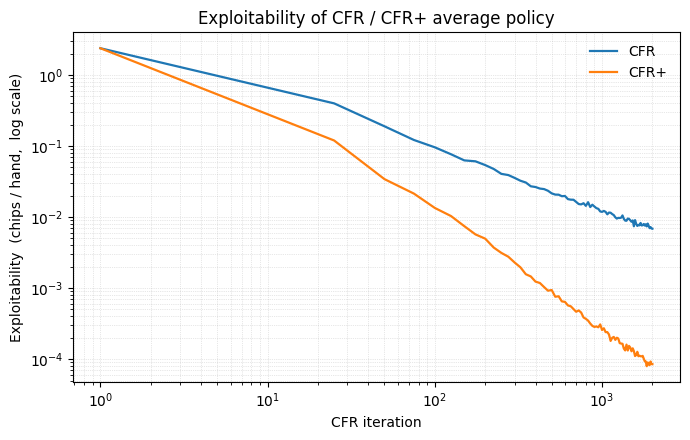

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for label, df in [("CFR", df_cfr), ("CFR+", df_cfrp)]:
    ax.plot(df["iteration"], df["exploitability"], label=label, linewidth=1.6)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("CFR iteration")
ax.set_ylabel("Exploitability  (chips / hand,  log scale)")
ax.set_title("Exploitability of CFR / CFR+ average policy")
ax.grid(True, which="both", linestyle=":", linewidth=0.5, alpha=0.6)
ax.legend(frameon=False)
fig.tight_layout()

for ext in ("pdf", "png"):
    fig.savefig(CONFIG.figures_dir / f"cfr_baseline.{ext}", dpi=160)
plt.show()


In [14]:
# Save the average policies. CFR+ converges faster and is the reference equilibrium
# for §7's head-to-head evaluation; CFR is kept for the per-method comparison.
def save_tabular_policy(tab_policy, path: Path) -> None:
    payload = {
        "action_probability_array": np.asarray(tab_policy.action_probability_array, dtype=np.float64),
        "state_lookup":             dict(tab_policy.state_lookup),
        "legal_actions_mask":       np.asarray(tab_policy.legal_actions_mask),
        "player_ids":               list(tab_policy.player_ids),
    }
    with open(path, "wb") as f:
        pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)


save_tabular_policy(avg_cfr,  CONFIG.checkpoints_dir / "cfr_avg_policy.pkl")
save_tabular_policy(avg_cfrp, CONFIG.checkpoints_dir / "cfr_plus_avg_policy.pkl")
print("saved:")
for p in sorted(CONFIG.checkpoints_dir.glob("*.pkl")):
    print(" ", p.relative_to(PROJECT_ROOT), f"({p.stat().st_size/1024:.1f} kB)")


saved:
  data/checkpoints/cfr_avg_policy.pkl (145.3 kB)
  data/checkpoints/cfr_plus_avg_policy.pkl (145.3 kB)


In [15]:
def load_tabular_policy(game, path: Path) -> "policy_lib.TabularPolicy":
    '''Rehydrate a saved average policy as a TabularPolicy on the given game.'''
    with open(path, "rb") as f:
        payload = pickle.load(f)
    tab = policy_lib.TabularPolicy(game)
    assert tab.action_probability_array.shape == payload["action_probability_array"].shape, (
        f"shape mismatch: ckpt {payload['action_probability_array'].shape} vs game {tab.action_probability_array.shape}"
    )
    tab.action_probability_array[:] = payload["action_probability_array"]
    return tab


# Round-trip check: reloaded policy must reproduce the trained exploitability.
reloaded = load_tabular_policy(game, CONFIG.checkpoints_dir / "cfr_plus_avg_policy.pkl")
expl_disk = exploitability.exploitability(game, reloaded)
expl_mem  = exploitability.exploitability(game, avg_cfrp)
print(f"CFR+ exploitability (in-memory) : {expl_mem:.6e}")
print(f"CFR+ exploitability (from disk) : {expl_disk:.6e}")
assert np.isclose(expl_disk, expl_mem), "save/load round-trip changed the policy!"
print("round-trip OK")


CFR+ exploitability (in-memory) : 8.497776e-05
CFR+ exploitability (from disk) : 8.497776e-05
round-trip OK


## §3 Deep CFR

**Theory.** Deep CFR (Brown et al., 2019) replaces CFR's per-infoset regret tables with neural networks. For each player $p$ an *advantage network* $V(I,a;\theta_p)$ approximates the cumulative counterfactual regret. Sampled instantaneous regrets $\tilde r$ from external-sampling Monte-Carlo traversals are stored with their iteration index $t$ in a reservoir, and $\theta_p$ minimizes the iteration-weighted MSE
$$\mathcal L(\theta_p)=\mathbb E_{(I,a,t,\tilde r)\sim\mathcal M_v}\big[t\,(V(I,a;\theta_p)-\tilde r)^2\big].$$
Traversal actions follow regret matching on $V$. A separate *strategy network* $\Pi(I;\theta_\Pi)$ is trained to imitate the iteration-weighted average of the sampled policies, $\mathcal L(\theta_\Pi)=\mathbb E_{(I,t,\sigma^t)\sim\mathcal M_\Pi}\big[t\,\lVert\Pi(I;\theta_\Pi)-\sigma^t(I)\rVert^2\big]$, and that network is the analogue of CFR's average policy (so it, not the advantage net, is what we evaluate).

Deep CFR (Brown et al., 2019) replaces CFR's exact regret tables with neural networks:
per-player **advantage networks** approximate the cumulative counterfactual regrets, and a
single **strategy network** is trained to imitate the iteration-weighted average of the
sampled policies. Regret-matching is applied to the advantage-network outputs to choose
actions, and the game tree is sampled by external-sampling Monte-Carlo traversals rather
than swept exhaustively. The strategy network is the object that converges to equilibrium —
it is the analogue of CFR's *average policy*, so it is what we evaluate and save.

We use OpenSpiel's PyTorch `DeepCFRSolver` (PyTorch-native). Its `solve()` runs the entire iteration loop and only returns the final network,
giving no curve. To trace exploitability over training we build the solver with
`num_iterations = deepcfr_eval_every` (the chunk size) and call `solve()` repeatedly: each
call continues filling the *same* reservoir buffers, advances the internal iteration
counter, and retrains the strategy network, so evaluating after each chunk yields a genuine
training trajectory using only the public API.

One correctness note: the strategy network's softmax is over *all* actions, so its mass on
the legal actions of an info set does not sum to 1, and OpenSpiel's exploitability reads
those raw values as reach probabilities. `deep_cfr_average_policy` renormalizes per info set
so the reported exploitability is unbiased.

**Expectation.** Deep CFR should drive exploitability down steadily but **plateau well above
the tabular CFR/CFR+ floor** (~1e-4): sampling variance and function-approximation error put
a floor on how close the neural average policy can get. That gap — neural approximation vs
exact regret minimization — is exactly the comparison this thesis is about.

In [16]:
def deep_cfr_average_policy(game, solver) -> "policy_lib.TabularPolicy":
    '''Materialize Deep CFR's strategy network as a normalized TabularPolicy.

    The strategy network ends in a softmax over *all* actions, so the mass it places on the
    legal actions of an info set does not sum to 1. OpenSpiel's exploitability routine reads
    those values directly as reach probabilities, so we renormalize per info set over the
    legal actions to get an unbiased exploitability estimate. The result is a standard
    TabularPolicy — identical in type to the §2 CFR average policies — so §7 can treat every
    method's output uniformly.
    '''
    n_actions = game.num_distinct_actions()
    tab = policy_lib.TabularPolicy(game)
    for idx, state in enumerate(tab.states):
        probs = solver.action_probabilities(state)        # {legal_action: prob}
        row = np.zeros(n_actions, dtype=np.float64)
        mass = float(sum(probs.values()))
        if mass > 0:
            for a, p in probs.items():
                row[a] = p / mass
        else:                                             # degenerate net output -> uniform
            for a in probs:
                row[a] = 1.0 / len(probs)
        tab.action_probability_array[idx, :] = row
    return tab

In [17]:
def train_deep_cfr(game, cfg: Config, *, seed: int):
    '''Train Deep CFR, logging exploitability of the strategy network over iterations.

    `solve()` runs the full loop in one shot and only returns the final network, so to get a
    curve we build the solver with `num_iterations = deepcfr_eval_every` and call `solve()`
    once per chunk: each call keeps filling the *same* reservoir buffers and advances the
    internal iteration counter, so evaluating between calls traces a real trajectory.

    Returns (tidy DataFrame matching PLAN §9, trained solver, final average TabularPolicy).
    '''
    set_global_seed(seed)
    solver = deep_cfr.DeepCFRSolver(
        game,
        policy_network_layers=cfg.deepcfr_policy_layers,
        advantage_network_layers=cfg.deepcfr_advantage_layers,
        num_iterations=cfg.deepcfr_eval_every,        # chunk size; we call solve() repeatedly
        num_traversals=cfg.deepcfr_num_traversals,
        learning_rate=cfg.deepcfr_learning_rate,
        batch_size_advantage=cfg.deepcfr_batch_size,
        batch_size_strategy=cfg.deepcfr_batch_size,
        policy_network_train_steps=cfg.deepcfr_train_steps,
        advantage_network_train_steps=cfg.deepcfr_train_steps,
        memory_capacity=cfg.deepcfr_memory_capacity,
        reinitialize_advantage_networks=True,
        device=cfg.deepcfr_device,
        seed=seed,
    )

    n_players = game.num_players()
    n_chunks = cfg.deepcfr_iterations // cfg.deepcfr_eval_every
    rows: list[dict] = []
    t0 = time.perf_counter()
    for chunk in tqdm(range(1, n_chunks + 1), desc=f"DeepCFR(seed={seed})", leave=False):
        solver.solve()                                # advances eval_every iterations
        iteration = chunk * cfg.deepcfr_eval_every
        avg_policy = deep_cfr_average_policy(game, solver)
        expl = exploitability.exploitability(game, avg_policy)
        rows.append({
            "method":         "DeepCFR",
            "seed":           seed,
            "iteration":      iteration,
            # sample budget so far = tree traversals (both players, every iteration).
            "episodes":       iteration * n_players * cfg.deepcfr_num_traversals,
            "wall_clock_s":   time.perf_counter() - t0,
            "exploitability": expl,
        })
    df = pd.DataFrame(rows)
    return df, solver, deep_cfr_average_policy(game, solver)

In [18]:
df_deepcfr, deepcfr_solver, avg_deepcfr = train_deep_cfr(
    game, CONFIG, seed=CONFIG.seeds[0],
)
df_deepcfr.tail(3)

,method,seed,iteration,episodes,wall_clock_s,exploitability
72,DeepCFR,0,146,11680,113.847043,0.273505
73,DeepCFR,0,148,11840,115.752792,0.255798
74,DeepCFR,0,150,12000,117.766809,0.260606


In [19]:
# Persist the per-iteration log so §10 can rebuild the figure without retraining.
csv_path = CONFIG.results_dir / "deep_cfr.csv"
df_deepcfr.to_csv(csv_path, index=False)
print(f"wrote {csv_path.relative_to(PROJECT_ROOT)}  ({len(df_deepcfr)} rows)")
print(f"final exploitability (DeepCFR, seed={CONFIG.seeds[0]}): "
      f"{df_deepcfr['exploitability'].iloc[-1]:.4f} chips/hand")

wrote data/results/deep_cfr.csv  (75 rows)
final exploitability (DeepCFR, seed=0): 0.2606 chips/hand


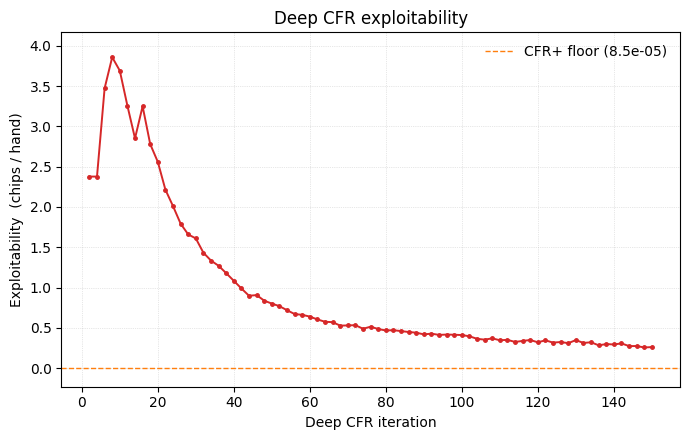

In [20]:
df_base = pd.read_csv(CONFIG.results_dir / "cfr_baseline.csv")
cfrp_floor = df_base[df_base["method"] == "CFR+"]["exploitability"].iloc[-1]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_deepcfr["iteration"], df_deepcfr["exploitability"], color="C3", linewidth=1.4, marker="o", markersize=2.5)
ax.axhline(cfrp_floor, linestyle="--", linewidth=1.0, color="C1", label=f"CFR+ floor ({cfrp_floor:.1e})")
ax.set_xlabel("Deep CFR iteration"); ax.set_ylabel("Exploitability  (chips / hand)")
ymax = df_deepcfr["exploitability"].max(); ax.set_ylim(-0.06 * ymax, ymax * 1.08)
ax.set_title("Deep CFR exploitability")
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6); ax.legend(frameon=False)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(CONFIG.figures_dir / f"deep_cfr.{ext}", dpi=160)
plt.show()

In [21]:
# Save the neural networks plus the metadata needed to rebuild them. PyTorch `.pt`
# for neural agents per PLAN §9. (`solver._policy_network` / `_advantage_networks` are
# the only handles OpenSpiel exposes to the weights — accessed read-only here.)
def save_deep_cfr(solver, cfg: Config, path: Path) -> None:
    payload = {
        "policy_network_state_dict":     solver._policy_network.state_dict(),
        "advantage_network_state_dicts": [n.state_dict() for n in solver._advantage_networks],
        "arch": {
            "policy_layers":    list(cfg.deepcfr_policy_layers),
            "advantage_layers": list(cfg.deepcfr_advantage_layers),
            "embedding_size":   solver._embedding_size,
            "num_actions":      solver._num_actions,
        },
    }
    torch.save(payload, path)


deepcfr_ckpt = CONFIG.checkpoints_dir / "deep_cfr.pt"
save_deep_cfr(deepcfr_solver, CONFIG, deepcfr_ckpt)
print(f"saved {deepcfr_ckpt.relative_to(PROJECT_ROOT)} ({deepcfr_ckpt.stat().st_size / 1024:.1f} kB)")

saved data/checkpoints/deep_cfr.pt (84.2 kB)


In [22]:
def load_deep_cfr(game, cfg: Config, path: Path):
    '''Rebuild a Deep CFR solver shell and load saved weights for inference.

    Constructs a fresh `DeepCFRSolver` (no training) with the saved architecture and copies
    the network weights in. Returns (solver, average TabularPolicy) so the reloaded model
    can be evaluated or played head-to-head in §7 without retraining.
    '''
    payload = torch.load(path, map_location=cfg.deepcfr_device, weights_only=False)
    arch = payload["arch"]
    solver = deep_cfr.DeepCFRSolver(
        game,
        policy_network_layers=tuple(arch["policy_layers"]),
        advantage_network_layers=tuple(arch["advantage_layers"]),
        num_iterations=cfg.deepcfr_eval_every,
        num_traversals=cfg.deepcfr_num_traversals,
        device=cfg.deepcfr_device,
    )
    solver._policy_network.load_state_dict(payload["policy_network_state_dict"])
    for net, sd in zip(solver._advantage_networks, payload["advantage_network_state_dicts"]):
        net.load_state_dict(sd)
    return solver, deep_cfr_average_policy(game, solver)


# Round-trip check: the reloaded strategy network must reproduce the trained exploitability.
reloaded_solver, reloaded_avg = load_deep_cfr(game, CONFIG, deepcfr_ckpt)
expl_disk = exploitability.exploitability(game, reloaded_avg)
expl_mem  = exploitability.exploitability(game, avg_deepcfr)
print(f"Deep CFR exploitability (in-memory) : {expl_mem:.6f}")
print(f"Deep CFR exploitability (from disk) : {expl_disk:.6f}")
assert np.isclose(expl_disk, expl_mem), "save/load round-trip changed the policy!"
print("round-trip OK")

Deep CFR exploitability (in-memory) : 0.260606
Deep CFR exploitability (from disk) : 0.260606
round-trip OK


## §4 NFSP (Neural Fictitious Self-Play)

**Theory.** NFSP (Heinrich & Silver, 2016) is neural *fictitious play*. Each agent keeps two networks. A best-response $Q(s,a;\theta_Q)$ is trained by DQN to minimize the temporal-difference loss
$$\mathcal L_{RL}=\mathbb E_{(s,a,r,s')\sim\mathcal M_{RL}}\big[(r+\gamma\textstyle\max_{a'}Q(s',a';\theta_Q^-)-Q(s,a;\theta_Q))^2\big],$$
and an average policy $\Pi(a|s;\theta_\Pi)$ is trained by supervised classification of the agent's own past best-response actions, $\mathcal L_{SL}=\mathbb E_{(s,a)\sim\mathcal M_{SL}}[-\log\Pi(a|s;\theta_\Pi)]$. Each episode the agent acts from the $\epsilon$-greedy best response with probability $\eta$ (the **anticipatory parameter**) and from $\Pi$ otherwise. The average policy tracks the fictitious-play average and converges to a Nash equilibrium in two-player zero-sum games — so $\Pi$, not the best response, is the iterate we evaluate.

NFSP (Heinrich & Silver, 2016) is the first of the two deep *self-play* methods. Each player
runs two networks: a **best-response network** (a DQN trained by reinforcement learning
against the opponent's current behaviour) and an **average-policy network** (trained by
supervised learning to imitate the player's own historical best-response actions, stored in
a reservoir buffer). Each episode a player acts from its RL best response with probability
`anticipatory_param` and from its average policy otherwise. Fictitious-play theory says the
**average policy** is the iterate that converges to a Nash equilibrium — so, exactly as with
CFR's average strategy and Deep CFR's strategy network, that average-policy network is what
we evaluate and save (`MODE.AVERAGE_POLICY`).

Unlike the CFR-family solvers, NFSP is driven by the OpenSpiel `rl_environment`: we run
self-play episodes, step both agents through each trajectory, and let them learn from their
own buffers. To compute exploitability we wrap the agents' average policies in an
`NFSPPolicies` object (the standard OpenSpiel evaluation shim) that exposes them as a single
joint `policy.Policy`, then hand that to the same exploitability ruler used throughout. The
PyTorch NFSP is confirmed available in this install (§0.1 / PLAN §5).

**Expectation.** NFSP converges, but **slowly and noisily**, to a floor well above the
tabular CFR+ result: it is sample-based, uses function approximation, and the average policy
chases a moving best response. On Leduc the exploitability descends steadily over ~10^6
episodes; reaching the literature's sub-0.1 floor takes several million more. The point for
the thesis is the *shape* — a genuine, if slow, descent toward equilibrium — to be
contrasted in §6 with PPO, which does not converge at all.

In [23]:
class NFSPPolicies(policy_lib.Policy):
    '''Joint average-policy wrapper so NFSP agents can be scored by the exploitability ruler.

    Adapted from OpenSpiel's nfsp_leduc example. For the current player it assembles the
    rl_environment TimeStep the agent expects, temporarily forces the agent into the given
    mode (AVERAGE_POLICY for evaluation), and returns its distribution over the legal actions.
    '''

    def __init__(self, env, agents, mode):
        n_players = env.game.num_players()
        super().__init__(env.game, list(range(n_players)))
        self._agents = agents
        self._mode = mode
        self._obs = {"info_state": [None] * n_players, "legal_actions": [None] * n_players}

    def action_probabilities(self, state, player_id=None):
        cur = state.current_player()
        legal = state.legal_actions(cur)
        self._obs["current_player"] = cur
        self._obs["info_state"][cur] = state.information_state_tensor(cur)
        self._obs["legal_actions"][cur] = legal
        ts = rl_environment.TimeStep(
            observations=self._obs, rewards=None, discounts=None, step_type=None)
        with self._agents[cur].temp_mode_as(self._mode):
            probs = self._agents[cur].step(ts, is_evaluation=True).probs
        return {a: probs[a] for a in legal}


def make_nfsp_agents(env, cfg: Config, *, seed: int):
    '''Construct one NFSP agent per player using the §0 config hyperparameters.

    The first block of kwargs configures NFSP itself; the second is forwarded through NFSP's
    **kwargs to the inner DQN best-response agent (replay buffer, target-net sync, epsilon
    schedule, discount).
    '''
    info_state_size = env.observation_spec()["info_state"][0]
    num_actions = env.action_spec()["num_actions"]
    kwargs = dict(
        reservoir_buffer_capacity=cfg.nfsp_reservoir_buffer_capacity,
        anticipatory_param=cfg.nfsp_anticipatory_param,
        batch_size=cfg.nfsp_batch_size,
        rl_learning_rate=cfg.nfsp_rl_learning_rate,
        sl_learning_rate=cfg.nfsp_sl_learning_rate,
        min_buffer_size_to_learn=cfg.nfsp_min_buffer_size_to_learn,
        learn_every=cfg.nfsp_learn_every,
        optimizer_str=cfg.nfsp_optimizer,
        # forwarded to the inner DQN best-response agent:
        replay_buffer_capacity=cfg.nfsp_replay_buffer_capacity,
        loss_str=cfg.nfsp_loss,
        update_target_network_every=cfg.nfsp_update_target_network_every,
        discount_factor=cfg.nfsp_discount_factor,
        epsilon_start=cfg.nfsp_epsilon_start,
        epsilon_end=cfg.nfsp_epsilon_end,
        epsilon_decay_duration=cfg.nfsp_train_episodes,
    )
    return [
        nfsp.NFSP(pid, info_state_size, num_actions, list(cfg.nfsp_hidden_layers),
                  seed=seed, **kwargs)
        for pid in range(env.game.num_players())
    ]

In [24]:
def train_nfsp(env, cfg: Config, *, seed: int):
    '''Run NFSP self-play, logging exploitability of the joint average policy over episodes.

    Each episode: reset the environment, step both agents through the trajectory (each agent
    both acts and stores transitions for its RL and SL networks), then give every agent the
    terminal time step so it can finish learning and resample its episode policy. Every
    `nfsp_eval_every` episodes we score the joint AVERAGE policy with the exploitability ruler.

    Returns (tidy DataFrame matching PLAN §9, list of trained agents, joint average policy).
    '''
    set_global_seed(seed)
    agents = make_nfsp_agents(env, cfg, seed=seed)
    joint_avg = NFSPPolicies(env, agents, nfsp.MODE.AVERAGE_POLICY)

    rows: list[dict] = []
    t0 = time.perf_counter()
    pbar = tqdm(range(1, cfg.nfsp_train_episodes + 1), desc=f"NFSP(seed={seed})", leave=False)
    for ep in pbar:
        ts = env.reset()
        while not ts.last():
            pid = ts.observations["current_player"]
            ts = env.step([agents[pid].step(ts).action])
        for agent in agents:                       # terminal step for both agents
            agent.step(ts)
        if ep % cfg.nfsp_eval_every == 0:
            expl = exploitability.exploitability(env.game, joint_avg)
            rows.append({
                "method":         "NFSP",
                "seed":           seed,
                "iteration":      ep,              # episode-based: iteration == episodes
                "episodes":       ep,
                "wall_clock_s":   time.perf_counter() - t0,
                "exploitability": expl,
            })
            pbar.set_postfix(expl=f"{expl:.3f}")
    pbar.close()
    return pd.DataFrame(rows), agents, joint_avg

In [25]:
env_nfsp = rl_environment.Environment(CONFIG.game_name, players=2)
df_nfsp, nfsp_agents, nfsp_joint = train_nfsp(env_nfsp, CONFIG, seed=CONFIG.seeds[0])
df_nfsp.tail(3)

,method,seed,iteration,episodes,wall_clock_s,exploitability
197,NFSP,0,990000,990000,582.460066,0.718419
198,NFSP,0,995000,995000,586.030179,0.720091
199,NFSP,0,1000000,1000000,589.623958,0.718052


In [26]:
# Persist the per-episode log so §10 can rebuild the figure without retraining.
csv_path = CONFIG.results_dir / "nfsp.csv"
df_nfsp.to_csv(csv_path, index=False)
print(f"wrote {csv_path.relative_to(PROJECT_ROOT)}  ({len(df_nfsp)} rows)")
print(f"final exploitability (NFSP, seed={CONFIG.seeds[0]}): "
      f"{df_nfsp['exploitability'].iloc[-1]:.4f} chips/hand")

wrote data/results/nfsp.csv  (200 rows)
final exploitability (NFSP, seed=0): 0.7181 chips/hand


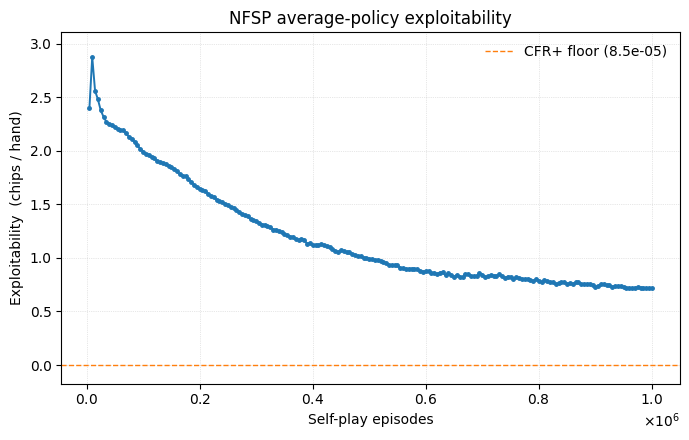

In [27]:
df_base = pd.read_csv(CONFIG.results_dir / "cfr_baseline.csv")
cfrp_floor = df_base[df_base["method"] == "CFR+"]["exploitability"].iloc[-1]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_nfsp["episodes"], df_nfsp["exploitability"], color="C0", linewidth=1.4, marker="o", markersize=2.5)
ax.axhline(cfrp_floor, linestyle="--", linewidth=1.0, color="C1", label=f"CFR+ floor ({cfrp_floor:.1e})")
ax.set_xlabel("Self-play episodes"); ax.set_ylabel("Exploitability  (chips / hand)")
ymax = df_nfsp["exploitability"].max(); ax.set_ylim(-0.06 * ymax, ymax * 1.08)
ax.set_title("NFSP average-policy exploitability")
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6); ax.legend(frameon=False)
ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0), useMathText=True)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(CONFIG.figures_dir / f"nfsp.{ext}", dpi=160)
plt.show()

In [28]:
# Save each player's average-policy (SL) network — the converging iterate. PyTorch `.pt`
# per PLAN §9. (`agent._avg_network` is OpenSpiel's handle to the SL net; accessed read-only.)
def save_nfsp(agents, env, cfg: Config, path: Path) -> None:
    payload = {
        "avg_network_state_dicts": [a._avg_network.state_dict() for a in agents],
        "arch": {
            "hidden_layers":   list(cfg.nfsp_hidden_layers),
            "info_state_size": env.observation_spec()["info_state"][0],
            "num_actions":     env.action_spec()["num_actions"],
        },
    }
    torch.save(payload, path)


nfsp_ckpt = CONFIG.checkpoints_dir / "nfsp.pt"
save_nfsp(nfsp_agents, env_nfsp, CONFIG, nfsp_ckpt)
print(f"saved {nfsp_ckpt.relative_to(PROJECT_ROOT)} ({nfsp_ckpt.stat().st_size / 1024:.1f} kB)")

saved data/checkpoints/nfsp.pt (37.3 kB)


In [29]:
def load_nfsp(env, cfg: Config, path: Path):
    '''Rebuild NFSP agents and load saved average-policy weights for evaluation / play.

    Constructs fresh NFSP agents (no training) and copies the saved SL-network weights in.
    Returns (agents, joint average policy) so §7 can play the reloaded model without
    retraining. Only the average policy is restored — the RL best-response net is not
    needed for evaluation.
    '''
    payload = torch.load(path, map_location="cpu", weights_only=False)
    arch = payload["arch"]
    agents = [
        nfsp.NFSP(pid, arch["info_state_size"], arch["num_actions"],
                  list(arch["hidden_layers"]),
                  reservoir_buffer_capacity=cfg.nfsp_reservoir_buffer_capacity,
                  anticipatory_param=cfg.nfsp_anticipatory_param,
                  min_buffer_size_to_learn=cfg.nfsp_min_buffer_size_to_learn)
        for pid in range(env.game.num_players())
    ]
    for agent, sd in zip(agents, payload["avg_network_state_dicts"]):
        agent._avg_network.load_state_dict(sd)
    return agents, NFSPPolicies(env, agents, nfsp.MODE.AVERAGE_POLICY)


# Round-trip check: reloaded average policy must reproduce the trained exploitability.
reloaded_agents, reloaded_joint = load_nfsp(env_nfsp, CONFIG, nfsp_ckpt)
expl_disk = exploitability.exploitability(env_nfsp.game, reloaded_joint)
expl_mem  = exploitability.exploitability(env_nfsp.game, nfsp_joint)
print(f"NFSP exploitability (in-memory) : {expl_mem:.6f}")
print(f"NFSP exploitability (from disk) : {expl_disk:.6f}")
assert np.isclose(expl_disk, expl_mem), "save/load round-trip changed the policy!"
print("round-trip OK")

NFSP exploitability (in-memory) : 0.718052
NFSP exploitability (from disk) : 0.718052
round-trip OK


## §5 Policy-gradient self-play (RMPG)

**Theory.** This is an actor–critic with a *regret-based* policy gradient (Srinivasan et al., 2018). A critic $q_w(s,a)$ estimates action values, giving advantages $A(s,a)=q_w(s,a)-\sum_b\pi_\theta(b|s)\,q_w(s,b)$. **RMPG** (regret-matching policy gradient; OpenSpiel `loss_str="rm"`) updates the policy toward the *regret-matching distribution* over positive advantages,
$$\pi^{\mathrm{RM}}(a|s)\propto\big[A(s,a)\big]^+,$$
the direct policy-gradient analogue of CFR's regret matching, with an entropy bonus $H[\pi]$ for exploration. Unlike NFSP there is **no separate averaging network**, so the *current* policy $\pi_\theta$ is the iterate we evaluate — which is why its exploitability is noisier and need not converge.

The second deep self-play method is **regret-based policy gradient** (Srinivasan et al.,
2018). Each player is an actor-critic agent: a critic estimates action values and a policy
network is updated by a *regret-matching* policy-gradient loss (**RMPG**) that pushes
probability toward actions with positive advantage — the policy-gradient analogue of CFR's
regret matching. OpenSpiel's `PolicyGradient` agent implements this family; we select RMPG
via `loss_str="rm"` (the variant PLAN §6 suggests; `rpg`/`qpg`/`a2c` are one-line swaps).

Mechanically this reuses the §4 self-play machinery — the same `rl_environment` loop and a
near-identical joint-policy wrapper. The key difference from NFSP: there is **no separate
averaging network**. RMPG drives the *current* policy toward equilibrium directly, so that
is the policy we evaluate and save, following the paper. `PolicyGradient._act` already masks
illegal actions and renormalizes, so the exploitability estimate needs no extra correction.

**Expectation, and a stability caveat.** RMPG reduces exploitability but is **much noisier
and less stable than NFSP**, plateauing at a far higher floor. Because the current policy is
evaluated with no averaging to damp it, aggressive learning rates make it *overshoot and
diverge* on Leduc.

In [30]:
PG_LABELS = {"rm": "RMPG", "rpg": "RPG", "qpg": "QPG", "a2c": "A2C", "neurd": "NeuRD"}


def pg_label(cfg: Config) -> str:
    '''Human-readable method name for the configured policy-gradient loss.'''
    return PG_LABELS.get(cfg.pg_loss, cfg.pg_loss.upper())


class PGPolicies(policy_lib.Policy):
    '''Joint current-policy wrapper so policy-gradient agents can be scored by the ruler.

    Like NFSPPolicies but with no mode switch: policy-gradient methods have a single policy
    network, which `step(is_evaluation=True)` already exposes as a legal-masked, normalized
    distribution (see PolicyGradient._act).
    '''

    def __init__(self, env, agents):
        n_players = env.game.num_players()
        super().__init__(env.game, list(range(n_players)))
        self._agents = agents
        self._obs = {"info_state": [None] * n_players, "legal_actions": [None] * n_players}

    def action_probabilities(self, state, player_id=None):
        cur = state.current_player()
        legal = state.legal_actions(cur)
        self._obs["current_player"] = cur
        self._obs["info_state"][cur] = state.information_state_tensor(cur)
        self._obs["legal_actions"][cur] = legal
        ts = rl_environment.TimeStep(
            observations=self._obs, rewards=None, discounts=None, step_type=None)
        probs = self._agents[cur].step(ts, is_evaluation=True).probs
        return {a: probs[a] for a in legal}


def make_pg_agents(env, cfg: Config, *, seed: int):
    '''Construct one PolicyGradient agent per player using the §0 config hyperparameters.

    PolicyGradient has no `seed` argument; reproducibility comes from `set_global_seed`
    (called before this) seeding torch's network initialization. Gradient clipping
    (`max_global_gradient_norm`) is essential here — without it RMPG diverges on Leduc.
    '''
    info_state_size = env.observation_spec()["info_state"][0]
    num_actions = env.action_spec()["num_actions"]
    return [
        policy_gradient.PolicyGradient(
            pid, info_state_size, num_actions,
            loss_str=cfg.pg_loss,
            hidden_layers_sizes=tuple(cfg.pg_hidden_layers),
            batch_size=cfg.pg_batch_size,
            critic_learning_rate=cfg.pg_critic_learning_rate,
            pi_learning_rate=cfg.pg_pi_learning_rate,
            entropy_cost=cfg.pg_entropy_cost,
            num_critic_before_pi=cfg.pg_num_critic_before_pi,
            max_global_gradient_norm=cfg.pg_max_global_gradient_norm,
            optimizer_str=cfg.pg_optimizer)
        for pid in range(env.game.num_players())
    ]

In [31]:
def train_pg(env, cfg: Config, *, seed: int):
    '''Run policy-gradient (RMPG) self-play, logging exploitability of the current policy.

    Same self-play loop as NFSP, but there is no averaging network: each agent's policy net
    is updated directly by the regret-based actor-critic loss, and that *current* policy is
    what we evaluate (Srinivasan et al., 2018). Critic/policy updates happen internally once
    each agent has gathered `pg_batch_size` episodes.

    Returns (tidy DataFrame matching PLAN §9, list of trained agents, joint policy).
    '''
    set_global_seed(seed)
    agents = make_pg_agents(env, cfg, seed=seed)
    joint = PGPolicies(env, agents)
    label = pg_label(cfg)

    rows: list[dict] = []
    t0 = time.perf_counter()
    pbar = tqdm(range(1, cfg.pg_train_episodes + 1), desc=f"{label}(seed={seed})", leave=False)
    for ep in pbar:
        ts = env.reset()
        while not ts.last():
            pid = ts.observations["current_player"]
            ts = env.step([agents[pid].step(ts).action])
        for agent in agents:                       # terminal step for both agents
            agent.step(ts)
        if ep % cfg.pg_eval_every == 0:
            expl = exploitability.exploitability(env.game, joint)
            rows.append({
                "method":         label,
                "seed":           seed,
                "iteration":      ep,              # episode-based: iteration == episodes
                "episodes":       ep,
                "wall_clock_s":   time.perf_counter() - t0,
                "exploitability": expl,
            })
            pbar.set_postfix(expl=f"{expl:.3f}")
    pbar.close()
    return pd.DataFrame(rows), agents, joint

In [32]:
env_pg = rl_environment.Environment(CONFIG.game_name, players=2)
df_pg, pg_agents, pg_joint = train_pg(env_pg, CONFIG, seed=CONFIG.seeds[0])
df_pg.tail(3)

RMPG(seed=0):   0%|          | 0/1000000 [00:00<?, ?it/s]/Users/dk/Developer/Leduc/.venv/lib/python3.13/site-packages/open_spiel/python/pytorch/policy_gradient.py:425: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:312.)
  value_predictions = q_values[list(action_indices)]


,method,seed,iteration,episodes,wall_clock_s,exploitability
197,RMPG,0,990000,990000,293.073607,1.547445
198,RMPG,0,995000,995000,294.472052,1.431442
199,RMPG,0,1000000,1000000,295.933650,1.456183


In [33]:
# Persist the per-episode log so §10 can rebuild the figure without retraining.
csv_path = CONFIG.results_dir / f"{pg_label(CONFIG).lower()}.csv"
df_pg.to_csv(csv_path, index=False)
print(f"wrote {csv_path.relative_to(PROJECT_ROOT)}  ({len(df_pg)} rows)")
print(f"final exploitability ({pg_label(CONFIG)}, seed={CONFIG.seeds[0]}): "
      f"{df_pg['exploitability'].iloc[-1]:.4f} chips/hand")

wrote data/results/rmpg.csv  (200 rows)
final exploitability (RMPG, seed=0): 1.4562 chips/hand


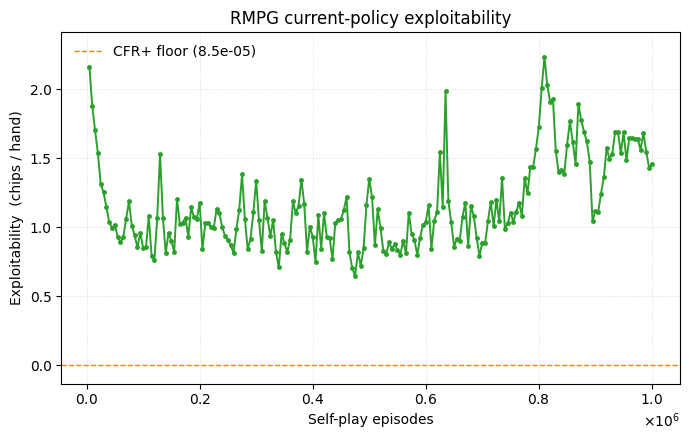

In [34]:
label = pg_label(CONFIG)
df_base = pd.read_csv(CONFIG.results_dir / "cfr_baseline.csv")
cfrp_floor = df_base[df_base["method"] == "CFR+"]["exploitability"].iloc[-1]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_pg["episodes"], df_pg["exploitability"], color="C2", linewidth=1.4, marker="o", markersize=2.5)
ax.axhline(cfrp_floor, linestyle="--", linewidth=1.0, color="C1", label=f"CFR+ floor ({cfrp_floor:.1e})")
ax.set_xlabel("Self-play episodes"); ax.set_ylabel("Exploitability  (chips / hand)")
ymax = df_pg["exploitability"].max(); ax.set_ylim(-0.06 * ymax, ymax * 1.08)
ax.set_title(f"{label} current-policy exploitability")
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6); ax.legend(frameon=False)
ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0), useMathText=True)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(CONFIG.figures_dir / f"{label.lower()}.{ext}", dpi=160)
plt.show()

In [35]:
# Save each player's policy path (torso + logits layer) — the iterate we evaluate. PyTorch
# `.pt` per PLAN §9. (`_net_torso` / `_policy_logits_layer` are exactly what `_act` uses.)
def save_pg(agents, env, cfg: Config, path: Path) -> None:
    payload = {
        "policy_state_dicts": [
            {"net_torso": a._net_torso.state_dict(),
             "policy_logits_layer": a._policy_logits_layer.state_dict()}
            for a in agents
        ],
        "arch": {
            "hidden_layers":   list(cfg.pg_hidden_layers),
            "info_state_size": env.observation_spec()["info_state"][0],
            "num_actions":     env.action_spec()["num_actions"],
            "loss":            cfg.pg_loss,
        },
    }
    torch.save(payload, path)


pg_ckpt = CONFIG.checkpoints_dir / f"{pg_label(CONFIG).lower()}.pt"
save_pg(pg_agents, env_pg, CONFIG, pg_ckpt)
print(f"saved {pg_ckpt.relative_to(PROJECT_ROOT)} ({pg_ckpt.stat().st_size / 1024:.1f} kB)")

saved data/checkpoints/rmpg.pt (37.4 kB)


In [36]:
def load_pg(env, cfg: Config, path: Path):
    '''Rebuild policy-gradient agents and load saved policy weights for evaluation / play.

    Restores only the policy path (`_net_torso` + `_policy_logits_layer`) — the critic is
    not needed to act. Returns (agents, joint policy) so §7 can play the reloaded model.
    '''
    payload = torch.load(path, map_location="cpu", weights_only=False)
    arch = payload["arch"]
    agents = [
        policy_gradient.PolicyGradient(
            pid, arch["info_state_size"], arch["num_actions"],
            loss_str=arch["loss"], hidden_layers_sizes=tuple(arch["hidden_layers"]))
        for pid in range(env.game.num_players())
    ]
    for agent, sd in zip(agents, payload["policy_state_dicts"]):
        agent._net_torso.load_state_dict(sd["net_torso"])
        agent._policy_logits_layer.load_state_dict(sd["policy_logits_layer"])
    return agents, PGPolicies(env, agents)


# Round-trip check: reloaded policy must reproduce the trained exploitability.
reloaded_pg_agents, reloaded_pg_joint = load_pg(env_pg, CONFIG, pg_ckpt)
expl_disk = exploitability.exploitability(env_pg.game, reloaded_pg_joint)
expl_mem  = exploitability.exploitability(env_pg.game, pg_joint)
print(f"{pg_label(CONFIG)} exploitability (in-memory) : {expl_mem:.6f}")
print(f"{pg_label(CONFIG)} exploitability (from disk) : {expl_disk:.6f}")
assert np.isclose(expl_disk, expl_mem), "save/load round-trip changed the policy!"
print("round-trip OK")

RMPG exploitability (in-memory) : 1.456183
RMPG exploitability (from disk) : 1.456183
round-trip OK


## §6 PPO self-play — the negative baseline

**Theory.** PPO (Schulman et al., 2017) is a strong single-agent policy-gradient method with **no equilibrium machinery** — no averaging, no regret matching. With probability ratio $\rho_t(\theta)=\pi_\theta(a_t|s_t)/\pi_{\theta_{\text{old}}}(a_t|s_t)$ and GAE advantage $\hat A_t$, it maximizes the *clipped surrogate*
$$\mathcal L^{\mathrm{CLIP}}(\theta)=\mathbb E_t\big[\min(\rho_t\hat A_t,\ \mathrm{clip}(\rho_t,1-\epsilon,1+\epsilon)\,\hat A_t)\big]$$
plus a value loss and entropy bonus. It only ever *best-responds* to its current data; in self-play the opponent is the agent's own moving policy — a non-stationary target — so PPO has no reason to converge to an equilibrium. That non-convergence is the point of including it.

PPO (Schulman et al., 2017) is a strong general-purpose deep-RL algorithm with **no
equilibrium machinery** — no averaging, no regret matching. Including it answers the obvious
question: *can a top single-agent RL method just "learn" a Nash equilibrium by self-play?*
On an imperfect-information game the expected answer is **no**: PPO best-responds to its
current opponent, so in self-play it chases a moving target and **cycles** instead of
converging. Showing that honestly is the entire point of this section — it motivates the
equilibrium-finding methods in §2–§5.

**Work-around.** OpenSpiel's PPO is adapted from CleanRL and is single-agent:
it always acts as one fixed seat and stores one transition per step, so it does not drop into
2-player turn-taking. We wrap it: `PPOSelfPlayEnv` presents the learner with a single-agent
MDP whose "environment" includes chance **and** the opponent — the opponent seat is auto-played
by the learner's *own current policy* (naive self-play), and the learner's seat is randomized
each episode so its single network experiences both positions. We feed the **information-state**
tensor (not the observation tensor the Atari example uses), since Leduc is imperfect-information
and the betting history matters. The CleanRL driving loop (`step` × `steps_per_batch` → `learn`)
is otherwise unchanged.

We score the current policy with the same exploitability ruler (`PPOPolicies` wraps the masked
actor). **Expectation:** a curve that dips then **oscillates indefinitely** in a wide band,
never approaching the CFR+ floor and at times no better than uniform random — the signature
non-convergence that makes PPO the negative control.

In [37]:
class PPOSelfPlayEnv:
    '''Single-agent self-play wrapper around turn-taking 2-player Leduc for OpenSpiel PPO.

    OpenSpiel's PPO is CleanRL-style and single-agent: it always acts as one fixed seat and
    buffers one transition per `step`. To use it on 2-player Leduc we present a single-agent
    MDP from the learner's perspective: the learner's seat is randomized each episode (so its
    one network experiences both positions), the opponent seat is auto-played by the learner's
    *current* policy (naive self-play), and chance + opponent moves are folded into the env
    transition. The returned TimeStep always exposes the learner at index 0 — the seat PPO is
    built with — and uses the information-state tensor (imperfect-info; betting history matters).
    '''

    def __init__(self, game, learner):
        self._game = game
        self._learner = learner
        self._na = game.num_distinct_actions()
        self._iss = game.information_state_tensor_size()
        self._state = None
        self._seat = None

    def _opponent_action(self, state):
        seat = state.current_player()
        obs = torch.Tensor(np.array([state.information_state_tensor(seat)]))
        mask = ppo.legal_actions_to_mask([state.legal_actions(seat)], self._na)
        with torch.no_grad():
            action, *_ = self._learner.get_action_and_value(obs, legal_actions_mask=mask)
        return int(action[0])

    def _advance_to_learner(self):
        st = self._state
        while not st.is_terminal():
            if st.is_chance_node():
                outcomes, probs = zip(*st.chance_outcomes())
                st.apply_action(int(np.random.choice(outcomes, p=probs)))
            elif st.current_player() == self._seat:
                break
            else:
                st.apply_action(self._opponent_action(st))

    def _learner_timestep(self):
        st = self._state
        if st.is_terminal():                                  # bootstrap-only obs
            info = np.zeros(self._iss, dtype=np.float32)
            legal = list(range(self._na))
        else:
            info = np.asarray(st.information_state_tensor(self._seat), dtype=np.float32)
            legal = st.legal_actions(self._seat)
        obs = {"info_state": [info, info], "legal_actions": [legal, legal], "current_player": 0}
        return rl_environment.TimeStep(
            observations=obs, rewards=None, discounts=None, step_type=None)

    def reset(self):
        self._state = self._game.new_initial_state()
        self._seat = int(np.random.randint(self._game.num_players()))
        self._advance_to_learner()
        if self._state.is_terminal():                         # guard (can't happen pre-action)
            return self.reset()
        return self._learner_timestep()

    def step(self, action):
        self._state.apply_action(int(action))
        self._advance_to_learner()
        if self._state.is_terminal():
            reward = self._state.returns()[self._seat]
            return self.reset(), reward, True                 # reset_if_done semantics
        return self._learner_timestep(), 0.0, False


class PPOPolicies(policy_lib.Policy):
    '''Wrap a PPO learner's current policy as a joint policy for the exploitability ruler.

    The same network plays both seats (the info-state tensor encodes position). PPO's masked
    categorical already returns a normalized distribution over legal actions, so there is no
    renormalization to do.
    '''

    def __init__(self, game, learner):
        super().__init__(game, list(range(game.num_players())))
        self._learner = learner
        self._na = game.num_distinct_actions()

    def action_probabilities(self, state, player_id=None):
        cur = state.current_player()
        legal = state.legal_actions(cur)
        obs = torch.Tensor(np.array([state.information_state_tensor(cur)]))
        mask = ppo.legal_actions_to_mask([legal], self._na)
        with torch.no_grad():
            *_, probs = self._learner.get_action_and_value(obs, legal_actions_mask=mask)
        probs = probs[0].cpu().numpy()
        return {a: float(probs[a]) for a in legal}

In [38]:
def make_ppo_learner(game, cfg: Config):
    '''Construct a single OpenSpiel PPO agent (PPOAgent MLP) for the learner seat.'''
    return ppo.PPO(
        input_shape=(game.information_state_tensor_size(),),
        num_actions=game.num_distinct_actions(),
        num_players=game.num_players(),
        player_id=0,
        num_envs=1,
        steps_per_batch=cfg.ppo_steps_per_batch,
        num_minibatches=cfg.ppo_num_minibatches,
        update_epochs=cfg.ppo_update_epochs,
        learning_rate=cfg.ppo_learning_rate,
        gae=True,
        gamma=cfg.ppo_gamma,
        gae_lambda=cfg.ppo_gae_lambda,
        clip_coef=cfg.ppo_clip_coef,
        entropy_coef=cfg.ppo_entropy_coef,
        value_coef=cfg.ppo_value_coef,
        max_grad_norm=cfg.ppo_max_grad_norm,
        device="cpu",
        agent_fn=ppo.PPOAgent,
    )


def train_ppo(game, cfg: Config, *, seed: int):
    '''Train PPO via naive self-play, logging current-policy exploitability over learner steps.

    The CleanRL-style driving loop (step x steps_per_batch -> learn) mirrors OpenSpiel's
    ppo_example, but `PPOSelfPlayEnv` makes the single agent a self-play learner. We evaluate
    the current policy every `ppo_eval_every_updates` updates.

    Returns (tidy DataFrame matching PLAN §9, trained PPO learner, joint policy wrapper).
    '''
    set_global_seed(seed)
    learner = make_ppo_learner(game, cfg)
    env = PPOSelfPlayEnv(game, learner)
    evaluator = PPOPolicies(game, learner)

    num_updates = cfg.ppo_total_steps // cfg.ppo_steps_per_batch
    rows: list[dict] = []
    t0 = time.perf_counter()
    time_step = [env.reset()]
    pbar = tqdm(range(num_updates), desc=f"PPO(seed={seed})", leave=False)
    for update in pbar:
        for _ in range(cfg.ppo_steps_per_batch):
            agent_output = learner.step(time_step)
            next_ts, reward, done = env.step(agent_output[0].action)
            learner.post_step([reward], [done])
            time_step = [next_ts]
        learner.learn(time_step)
        if update % cfg.ppo_eval_every_updates == 0 or update == num_updates - 1:
            expl = exploitability.exploitability(game, evaluator)
            rows.append({
                "method":         "PPO",
                "seed":           seed,
                "iteration":      update + 1,
                "episodes":       learner.total_steps_done,    # learner decisions so far
                "wall_clock_s":   time.perf_counter() - t0,
                "exploitability": expl,
            })
            pbar.set_postfix(expl=f"{expl:.3f}")
    pbar.close()
    return pd.DataFrame(rows), learner, evaluator

In [39]:
df_ppo, ppo_learner, ppo_joint = train_ppo(game, CONFIG, seed=CONFIG.seeds[0])
df_ppo.tail(3)

,method,seed,iteration,episodes,wall_clock_s,exploitability
198,PPO,0,2971,380288,233.943107,1.359769
199,PPO,0,2986,382208,235.108866,1.355660
200,PPO,0,3000,384000,236.395447,1.362049


In [40]:
# Persist the per-update log so §10 can rebuild the figure without retraining.
csv_path = CONFIG.results_dir / "ppo.csv"
df_ppo.to_csv(csv_path, index=False)
print(f"wrote {csv_path.relative_to(PROJECT_ROOT)}  ({len(df_ppo)} rows)")
print(f"final exploitability (PPO, seed={CONFIG.seeds[0]}): "
      f"{df_ppo['exploitability'].iloc[-1]:.4f} chips/hand")
print(f"min / max over training        : "
      f"{df_ppo['exploitability'].min():.4f} / {df_ppo['exploitability'].max():.4f}  "
      f"(wide band = non-convergence)")

wrote data/results/ppo.csv  (201 rows)
final exploitability (PPO, seed=0): 1.3620 chips/hand
min / max over training        : 0.7812 / 2.3317  (wide band = non-convergence)


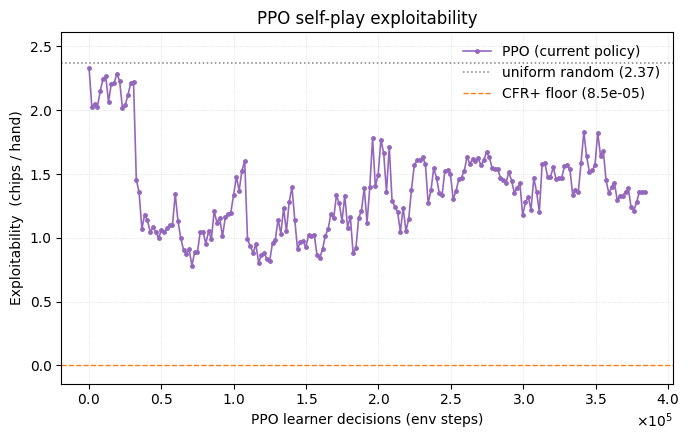

In [41]:
df_base = pd.read_csv(CONFIG.results_dir / "cfr_baseline.csv")
cfrp_floor = df_base[df_base["method"] == "CFR+"]["exploitability"].iloc[-1]
uniform = policy_lib.tabular_policy_from_callable(
    game, policy_lib.UniformRandomPolicy(game).action_probabilities)
uniform_expl = exploitability.exploitability(game, uniform)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_ppo["episodes"], df_ppo["exploitability"], color="C4", linewidth=1.2, marker="o", markersize=2.5, label="PPO (current policy)")
ax.axhline(uniform_expl, linestyle=":", linewidth=1.1, color="gray", label=f"uniform random ({uniform_expl:.2f})")
ax.axhline(cfrp_floor, linestyle="--", linewidth=1.0, color="C1", label=f"CFR+ floor ({cfrp_floor:.1e})")
ax.set_xlabel("PPO learner decisions (env steps)"); ax.set_ylabel("Exploitability  (chips / hand)")
ax.set_ylim(-0.06 * uniform_expl, uniform_expl * 1.1)
ax.set_title("PPO self-play exploitability")
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6); ax.legend(frameon=False)
ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0), useMathText=True)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(CONFIG.figures_dir / f"ppo.{ext}", dpi=160)
plt.show()

In [42]:
# Save the PPO actor-critic network (the learner's current policy). PyTorch `.pt` per PLAN §9.
def save_ppo(learner, game, path: Path) -> None:
    payload = {
        "network_state_dict": learner.state_dict(),
        "arch": {
            "info_state_size": game.information_state_tensor_size(),
            "num_actions":     game.num_distinct_actions(),
            "num_players":     game.num_players(),
        },
    }
    torch.save(payload, path)


ppo_ckpt = CONFIG.checkpoints_dir / "ppo.pt"
save_ppo(ppo_learner, game, ppo_ckpt)
print(f"saved {ppo_ckpt.relative_to(PROJECT_ROOT)} ({ppo_ckpt.stat().st_size / 1024:.1f} kB)")

saved data/checkpoints/ppo.pt (53.4 kB)


In [43]:
def load_ppo(game, cfg: Config, path: Path):
    '''Rebuild a PPO learner and load saved actor-critic weights for evaluation / play.

    Returns (learner, joint policy) so §7 can play the reloaded model without retraining.
    '''
    payload = torch.load(path, map_location="cpu", weights_only=False)
    learner = make_ppo_learner(game, cfg)
    learner.load_state_dict(payload["network_state_dict"])
    return learner, PPOPolicies(game, learner)


# Round-trip check: reloaded policy must reproduce the trained exploitability.
reloaded_ppo, reloaded_ppo_joint = load_ppo(game, CONFIG, ppo_ckpt)
expl_disk = exploitability.exploitability(game, reloaded_ppo_joint)
expl_mem  = exploitability.exploitability(game, ppo_joint)
print(f"PPO exploitability (in-memory) : {expl_mem:.6f}")
print(f"PPO exploitability (from disk) : {expl_disk:.6f}")
assert np.isclose(expl_disk, expl_mem), "save/load round-trip changed the policy!"
print("round-trip OK")

PPO exploitability (in-memory) : 1.362049
PPO exploitability (from disk) : 1.362049
round-trip OK


## §7 Head-to-head evaluation

Exploitability measures each policy against its *worst-case* adversary. Head-to-head asks a
different, complementary question: when the trained strategies actually **play each
other**, and play the near-exact CFR+ equilibrium, who wins, and by how much?

Because Leduc is tiny we compute every match-up **exactly** by full game-tree expectation
(`expected_game_score.policy_value`) — no sampled games, no Monte-Carlo noise. Each value is
**seat-averaged** (the row method's expected value averaged over playing as player 0 and as
player 1), which cancels Leduc's first-mover advantage and leaves pure strategic edge.

**Sign convention.** Entry `[row, col]` is the **chips/hand the row method wins from the
column method** (seat-averaged); positive means the row method is stronger. The matrix is
therefore antisymmetric with a zero diagonal. We also report **mbb/g** (milli-big-blinds per
game): Leduc has no blind, so we fix `1 big blind := 1 ante chip`, giving
`mbb/g = 1000 x chips/hand`. Every policy is reloaded from its §2-§6 checkpoint, so this
section runs on its own without retraining.

In [44]:
# Reload every trained policy from its checkpoint (no retraining) and materialize each as a
# normalized TabularPolicy, so all methods are compared through one fast, uniform interface.
env_eval = rl_environment.Environment(CONFIG.game_name, players=2)


def tabular_from_policy(game, pol) -> "policy_lib.TabularPolicy":
    '''Materialize any Policy as a TabularPolicy, renormalizing per info set over legal
    actions so head-to-head values are unbiased regardless of how the source policy scales.'''
    n_actions = game.num_distinct_actions()
    tab = policy_lib.TabularPolicy(game)
    for idx, state in enumerate(tab.states):
        probs = pol.action_probabilities(state)
        row = np.zeros(n_actions, dtype=np.float64)
        mass = float(sum(probs.values()))
        if mass > 0:
            for a, p in probs.items():
                row[a] = p / mass
        else:
            legal = state.legal_actions()
            for a in legal:
                row[a] = 1.0 / len(legal)
        tab.action_probability_array[idx, :] = row
    return tab


_, dcfr_avg = load_deep_cfr(game, CONFIG, CONFIG.checkpoints_dir / "deep_cfr.pt")
_, nfsp_avg = load_nfsp(env_eval, CONFIG, CONFIG.checkpoints_dir / "nfsp.pt")
_, rmpg_pol = load_pg(env_eval, CONFIG, CONFIG.checkpoints_dir / f"{pg_label(CONFIG).lower()}.pt")
_, ppo_pol  = load_ppo(game, CONFIG, CONFIG.checkpoints_dir / "ppo.pt")
uniform_pol = policy_lib.tabular_policy_from_callable(
    game, policy_lib.UniformRandomPolicy(game).action_probabilities)

raw_policies = {
    "CFR+":           load_tabular_policy(game, CONFIG.checkpoints_dir / "cfr_plus_avg_policy.pkl"),
    "CFR":            load_tabular_policy(game, CONFIG.checkpoints_dir / "cfr_avg_policy.pkl"),
    "DeepCFR":        dcfr_avg,
    "NFSP":           nfsp_avg,
    pg_label(CONFIG): rmpg_pol,
    "PPO":            ppo_pol,
    "Uniform":        uniform_pol,
}
policies_h2h = {name: tabular_from_policy(game, pol) for name, pol in raw_policies.items()}

print("reloaded policies (own-exploitability sanity check vs each section's final value):")
for name, pol in policies_h2h.items():
    print(f"  {name:8s} exploitability = {exploitability.exploitability(game, pol):.4f}")

reloaded policies (own-exploitability sanity check vs each section's final value):
  CFR+     exploitability = 0.0001
  CFR      exploitability = 0.0068
  DeepCFR  exploitability = 0.2606
  NFSP     exploitability = 0.7181
  RMPG     exploitability = 1.4562
  PPO      exploitability = 1.3620
  Uniform  exploitability = 2.3736


In [45]:
def head_to_head(game, row_pol, col_pol) -> float:
    '''Exact, seat-averaged expected value in chips/hand to the ROW player.

    Averaging the row player's value over both seats removes Leduc's first-mover advantage,
    so the number reflects pure strategic edge. Computed by exact full-tree expectation
    (expected_game_score.policy_value) — no sampling noise.
    '''
    init = game.new_initial_state()
    v_as_p0 = expected_game_score.policy_value(init, [row_pol, col_pol])[0]
    v_as_p1 = expected_game_score.policy_value(init, [col_pol, row_pol])[1]
    return 0.5 * (v_as_p0 + v_as_p1)


names = list(policies_h2h)
matrix = np.zeros((len(names), len(names)))
for i, r in enumerate(names):
    for j, c in enumerate(names):
        if i != j:
            matrix[i, j] = head_to_head(game, policies_h2h[r], policies_h2h[c])

h2h_chips = pd.DataFrame(matrix, index=names, columns=names)
h2h_mbbg = h2h_chips * 1000.0   # 1 big blind := 1 ante chip  ->  mbb/g = 1000 x chips/hand
h2h_chips.round(4)

,CFR+,CFR,DeepCFR,NFSP,RMPG,PPO,Uniform
CFR+,0.0000,0.0022,0.0712,0.2221,0.2962,0.5045,0.7072
CFR,-0.0022,0.0000,0.0763,0.2357,0.2775,0.5083,0.7032
DeepCFR,-0.0712,-0.0763,0.0000,0.1901,0.2713,0.4762,0.8167
NFSP,-0.2221,-0.2357,-0.1901,0.0000,0.2269,0.4087,1.1609
RMPG,-0.2962,-0.2775,-0.2713,-0.2269,0.0000,0.1794,0.9867
PPO,-0.5045,-0.5083,-0.4762,-0.4087,-0.1794,0.0000,0.3174
Uniform,-0.7072,-0.7032,-0.8167,-1.1609,-0.9867,-0.3174,0.0000


In [46]:
# Persist both unit versions so §10 / the thesis can rebuild the table without recomputing.
h2h_chips.to_csv(CONFIG.results_dir / "head_to_head_chips.csv")
h2h_mbbg.to_csv(CONFIG.results_dir / "head_to_head_mbbg.csv")
print(f"wrote head_to_head_chips.csv and head_to_head_mbbg.csv to "
      f"{CONFIG.results_dir.relative_to(PROJECT_ROOT)}/\n")

print("Head-to-head — chips/hand to ROW vs COLUMN (seat-averaged, exact):")
print(h2h_chips.round(3).to_string())

# Headline summaries: mean edge over the field, and value vs the near-Nash CFR+ equilibrium.
field = [n for n in names if n != "Uniform"]
mean_edge = h2h_chips.loc[field, field].mean(axis=1).sort_values(ascending=False)
vs_cfrp = h2h_chips["CFR+"].drop("CFR+").sort_values()

print("\nMean edge over the field (mbb/g, excl. Uniform), strongest first:")
print((mean_edge * 1000).round(1).to_string())
print("\nValue when playing AGAINST the CFR+ equilibrium (chips/hand; <= 0 expected, "
      "closer to 0 = closer to equilibrium):")
print(vs_cfrp.round(4).to_string())

wrote head_to_head_chips.csv and head_to_head_mbbg.csv to data/results/

Head-to-head — chips/hand to ROW vs COLUMN (seat-averaged, exact):
          CFR+    CFR  DeepCFR   NFSP   RMPG    PPO  Uniform
CFR+     0.000  0.002    0.071  0.222  0.296  0.504    0.707
CFR     -0.002  0.000    0.076  0.236  0.278  0.508    0.703
DeepCFR -0.071 -0.076    0.000  0.190  0.271  0.476    0.817
NFSP    -0.222 -0.236   -0.190  0.000  0.227  0.409    1.161
RMPG    -0.296 -0.278   -0.271 -0.227  0.000  0.179    0.987
PPO     -0.504 -0.508   -0.476 -0.409 -0.179  0.000    0.317
Uniform -0.707 -0.703   -0.817 -1.161 -0.987 -0.317    0.000

Mean edge over the field (mbb/g, excl. Uniform), strongest first:
CFR+       182.7
CFR        182.6
DeepCFR    131.7
NFSP        -2.1
RMPG      -148.7
PPO       -346.2

Value when playing AGAINST the CFR+ equilibrium (chips/hand; <= 0 expected, closer to 0 = closer to equilibrium):
Uniform   -0.7072
PPO       -0.5045
RMPG      -0.2962
NFSP      -0.2221
DeepCFR   -0.071

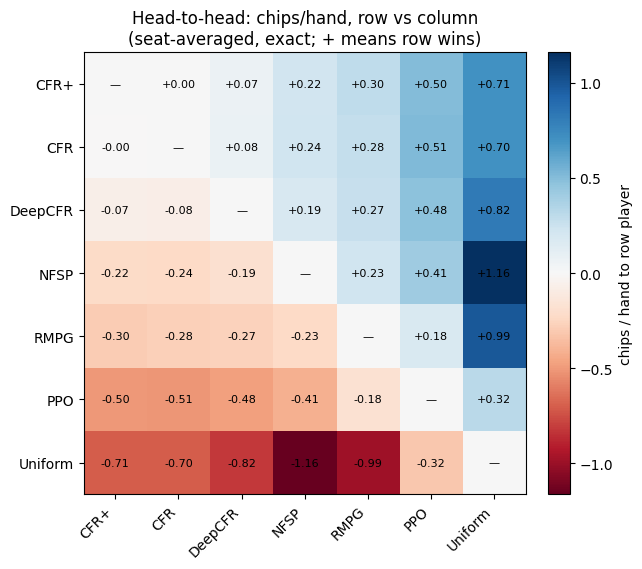

In [47]:
fig, ax = plt.subplots(figsize=(6.8, 5.8))
vmax = float(np.abs(h2h_chips.values).max())
im = ax.imshow(h2h_chips.values, cmap="RdBu", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
for i in range(len(names)):
    for j in range(len(names)):
        txt = "—" if i == j else f"{h2h_chips.values[i, j]:+.2f}"
        ax.text(j, i, txt, ha="center", va="center", fontsize=8, color="black")
ax.set_title("Head-to-head: chips/hand, row vs column\n(seat-averaged, exact; + means row wins)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="chips / hand to row player")
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(CONFIG.figures_dir / f"head_to_head.{ext}", dpi=160)
plt.show()

## 3-player Leduc — where deep self-play struggles

Everything so far lived in **2-player zero-sum** Leduc, where a Nash equilibrium is unique in value and the CFR family
provably converges to it. **3-player** Leduc breaks both assumptions: equilibria are no
longer unique, and none of the self-play methods carry a convergence guarantee. The question
is empirical — *what actually happens?*

Two things change mechanically:

1. **Metric.** Exploitability is defined only for 2-player zero-sum games (OpenSpiel raises
   on 3 players), so we switch to **NashConv** = the summed incentive of all players to
   deviate to a best response. NashConv >= 0, and = 0 only at a Nash equilibrium.
2. **Cost.** 3-player Leduc has **25,800 information sets** (vs 936) and a 47-dim info-state
   tensor, so one NashConv evaluation takes ~25 s. We therefore evaluate at a handful of
   milestones and use deliberately modest budgets — the goal is the *qualitative* picture,
   not a tuned 3-player solver.

We rerun a representative slate — **CFR** (tabular reference), and the three deep
*self-play* methods **NFSP**, **RMPG**, and **PPO** — reusing the exact builders and wrappers
from §2-§6 (they read sizes from the game/env, so they adapt to 47-dim inputs automatically).
Deep CFR is omitted here only for runtime; it is a one-line addition.

**Expectation.** CFR's average policy should drive NashConv down substantially (it is not
guaranteed to reach a Nash equilibrium with 3 players, but empirically it gets close-ish).
The deep self-play methods are expected to **plateau far higher** and stay there — this is
the headline negative result: techniques that approached equilibrium in 2 players visibly
stall once a third player breaks the zero-sum structure.

In [48]:
# Build 3-player Leduc and a NashConv helper. NashConv replaces exploitability (2p-only).
game3 = pyspiel.load_game(CONFIG.game_name, {"players": CONFIG.p3_players})
env3 = rl_environment.Environment(CONFIG.game_name, players=CONFIG.p3_players)
n_infosets_3p = len(policy_lib.TabularPolicy(game3).states)
print(f"3-player Leduc: players={game3.num_players()}  info_state={game3.information_state_tensor_size()}"
      f"  actions={game3.num_distinct_actions()}  info_sets={n_infosets_3p}")


def nash_conv_of(game, pol) -> float:
    '''NashConv of a joint policy. We materialize wrappers to a TabularPolicy first
    (tabular_from_policy, §7) so the best-response traversal does dict lookups instead of
    repeated network forwards — a large speed-up on the 25,800-state 3-player tree.'''
    return float(exploitability.nash_conv(game, tabular_from_policy(game, pol)))


uniform_nc_3p = nash_conv_of(game3, policy_lib.tabular_policy_from_callable(
    game3, policy_lib.UniformRandomPolicy(game3).action_probabilities))
print(f"NashConv of uniform-random (3p) = {uniform_nc_3p:.3f}   (the ceiling to beat)")

3-player Leduc: players=3  info_state=47  actions=3  info_sets=25800
NashConv of uniform-random (3p) = 12.611   (the ceiling to beat)


In [49]:
def _milestones(total, n):
    '''n roughly-even milestone counts in (0, total], always including total.'''
    return sorted(set(int(round(total * (k + 1) / n)) for k in range(n)))


def train_cfr_3p(game, cfg, *, seed=0):
    '''Tabular CFR on 3-player Leduc; logs NashConv of the average policy (the reference).'''
    set_global_seed(seed)
    solver = cfr.CFRSolver(game)
    eval_at = set(cfg.p3_cfr_eval_iters)
    rows, t0 = [], time.perf_counter()
    for it in tqdm(range(1, cfg.p3_cfr_iterations + 1), desc="CFR-3p", leave=False):
        solver.evaluate_and_update_policy()
        if it in eval_at:
            rows.append({"method": "CFR", "seed": seed, "x": it, "unit": "CFR iters",
                         "progress": it / cfg.p3_cfr_iterations,
                         "wall_clock_s": time.perf_counter() - t0,
                         "nash_conv": nash_conv_of(game, solver.average_policy())})
    return pd.DataFrame(rows), solver.average_policy()


def _train_selfplay_3p(env, agents, joint, total_episodes, label, seed):
    '''Shared episode loop for the episode-based deep methods (NFSP, RMPG) on 3 players.
    Evaluates the *untrained* policy first so every curve starts at progress 0.'''
    rows, t0, ep = [], time.perf_counter(), 0
    pbar = tqdm(total=total_episodes, desc=f"{label}-3p", leave=False)
    rows.append({"method": label, "seed": seed, "x": 0, "unit": "episodes", "progress": 0.0,
                 "wall_clock_s": 0.0, "nash_conv": nash_conv_of(env.game, joint)})
    for target in _milestones(total_episodes, CONFIG.p3_deep_eval_points):
        while ep < target:
            ts = env.reset()
            while not ts.last():
                pid = ts.observations["current_player"]
                ts = env.step([agents[pid].step(ts).action])
            for a in agents:
                a.step(ts)
            ep += 1
            pbar.update(1)
        nc_val = nash_conv_of(env.game, joint)
        rows.append({"method": label, "seed": seed, "x": ep, "unit": "episodes",
                     "progress": ep / total_episodes,
                     "wall_clock_s": time.perf_counter() - t0, "nash_conv": nc_val})
        pbar.set_postfix(nc=f"{nc_val:.2f}")
    pbar.close()
    return pd.DataFrame(rows), joint


def train_nfsp_3p(env, cfg, *, seed=0):
    set_global_seed(seed)
    cfg_n = replace(cfg, nfsp_train_episodes=cfg.p3_nfsp_episodes)   # match epsilon schedule
    agents = make_nfsp_agents(env, cfg_n, seed=seed)
    joint = NFSPPolicies(env, agents, nfsp.MODE.AVERAGE_POLICY)
    return _train_selfplay_3p(env, agents, joint, cfg.p3_nfsp_episodes, "NFSP", seed)


def train_pg_3p(env, cfg, *, seed=0):
    set_global_seed(seed)
    agents = make_pg_agents(env, cfg, seed=seed)
    joint = PGPolicies(env, agents)
    return _train_selfplay_3p(env, agents, joint, cfg.p3_pg_episodes, pg_label(cfg), seed)


def train_ppo_3p(game, cfg, *, seed=0):
    set_global_seed(seed)
    learner = make_ppo_learner(game, cfg)
    penv = PPOSelfPlayEnv(game, learner)
    joint = PPOPolicies(game, learner)
    num_updates = cfg.p3_ppo_steps // cfg.ppo_steps_per_batch
    eval_at = set(_milestones(num_updates, cfg.p3_deep_eval_points))
    rows, t0 = [], time.perf_counter()
    rows.append({"method": "PPO", "seed": seed, "x": 0, "unit": "env steps", "progress": 0.0,
                 "wall_clock_s": 0.0, "nash_conv": nash_conv_of(game, joint)})
    time_step = [penv.reset()]
    pbar = tqdm(range(num_updates), desc="PPO-3p", leave=False)
    for update in pbar:
        for _ in range(cfg.ppo_steps_per_batch):
            out = learner.step(time_step)
            nts, r, d = penv.step(out[0].action)
            learner.post_step([r], [d])
            time_step = [nts]
        learner.learn(time_step)
        if (update + 1) in eval_at:
            nc_val = nash_conv_of(game, joint)
            rows.append({"method": "PPO", "seed": seed, "x": learner.total_steps_done,
                         "unit": "env steps", "progress": (update + 1) / num_updates,
                         "wall_clock_s": time.perf_counter() - t0, "nash_conv": nc_val})
            pbar.set_postfix(nc=f"{nc_val:.2f}")
    pbar.close()
    return pd.DataFrame(rows), joint

In [50]:
# Run the slate on 3-player Leduc. Slow — dominated by the ~25 s NashConv evals and the
# 3-player self-play rollouts (a few minutes per method on CPU).
df_cfr3,  avg_cfr3   = train_cfr_3p(game3, CONFIG)
df_nfsp3, nfsp3_joint = train_nfsp_3p(env3, CONFIG)
df_rmpg3, rmpg3_joint = train_pg_3p(env3, CONFIG)
df_ppo3,  ppo3_joint  = train_ppo_3p(game3, CONFIG)

df_3p = pd.concat([df_cfr3, df_nfsp3, df_rmpg3, df_ppo3], ignore_index=True)
df_3p[["method", "x", "unit", "wall_clock_s", "nash_conv"]]

RMPG-3p:   0%|          | 1/200000 [00:28<1590:49:29, 28.63s/it]           /Users/dk/Developer/Leduc/.venv/lib/python3.13/site-packages/open_spiel/python/pytorch/policy_gradient.py:425: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:312.)
  value_predictions = q_values[list(action_indices)]


,method,x,unit,wall_clock_s,nash_conv
0,CFR,1,CFR iters,15.121821,12.611221
1,CFR,3,CFR iters,65.633815,7.944986
2,CFR,5,CFR iters,113.760401,6.060365
3,CFR,8,CFR iters,173.199003,4.202356
4,CFR,11,CFR iters,232.979962,3.181388
...,...,...,...,...,...
76,PPO,119936,env steps,523.512083,5.593007
77,PPO,127360,env steps,554.570304,5.574039
78,PPO,134912,env steps,585.664963,4.606193
79,PPO,142336,env steps,616.582285,3.793646


In [51]:
# Persist the per-milestone NashConv log so §10 / the thesis can rebuild the figure.
csv_path = CONFIG.results_dir / "three_player_nashconv.csv"
df_3p.to_csv(csv_path, index=False)
print(f"wrote {csv_path.relative_to(PROJECT_ROOT)}  ({len(df_3p)} rows)\n")

final_nc = df_3p.sort_values("progress").groupby("method").tail(1).set_index("method")["nash_conv"]
print("Final NashConv on 3-player Leduc (lower = closer to equilibrium):")
print(f"  {'uniform random':14s} {uniform_nc_3p:6.3f}")
for m in ["CFR", "NFSP", pg_label(CONFIG), "PPO"]:
    if m in final_nc.index:
        print(f"  {m:14s} {final_nc[m]:6.3f}")

wrote data/results/three_player_nashconv.csv  (81 rows)

Final NashConv on 3-player Leduc (lower = closer to equilibrium):
  uniform random 12.611
  CFR             0.878
  NFSP            7.364
  RMPG            5.656
  PPO             4.469


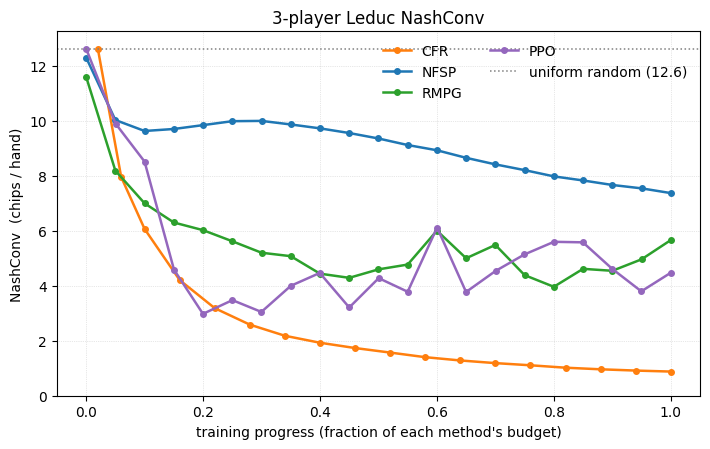

In [52]:
order = ["CFR", "NFSP", pg_label(CONFIG), "PPO"]
colors = {"CFR": "C1", "NFSP": "C0", pg_label(CONFIG): "C2", "PPO": "C4"}
fig, ax = plt.subplots(figsize=(7.2, 4.6))
for m in order:
    sub = df_3p[df_3p["method"] == m].sort_values("progress")
    if len(sub):
        ax.plot(sub["progress"], sub["nash_conv"], marker="o", markersize=4,
                linewidth=1.8, label=m, color=colors.get(m))
ax.axhline(uniform_nc_3p, linestyle=":", linewidth=1.1, color="gray",
           label=f"uniform random ({uniform_nc_3p:.1f})")
ax.set_ylim(0, uniform_nc_3p * 1.05)
ax.set_xlabel("training progress (fraction of each method's budget)")
ax.set_ylabel("NashConv  (chips / hand)")
ax.set_title("3-player Leduc NashConv")
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(CONFIG.figures_dir / f"three_player_nashconv.{ext}", dpi=160)
plt.show()

## §9 Robustness and sensitivity

A single training curve cannot support a claim like "NFSP converges" — the deep methods are
stochastic (random init, sampled trajectories, replay/reservoir shuffling), so we must show
they behave *reproducibly*. This section answers **RQ3**: how sensitive and
reproducible are the deep methods across seeds and key hyperparameters, and do they actually
converge?

Two experiments, both on 2-player Leduc (so the exploitability ruler is cheap):

1. **Multi-seed bands.** Each deep method (Deep CFR, NFSP, RMPG, PPO) is trained over
   **5 random seeds**; we plot the mean exploitability with a ±1 std shaded band. Reduced
   budgets vs §3-§6 keep 5×4 runs affordable — the band width (variance), not the exact
   floor, is what matters here.
2. **Hyperparameter sweep.** A small sweep of NFSP's **anticipatory parameter η** (the
   probability of acting from the RL best response each episode — the canonical NFSP knob),
   over η ∈ {0.05, 0.1, 0.5} with a couple of seeds each.

Both reuse the exact `train_*` functions from §3-§6 with budgets/hyperparameters swapped in
via `dataclasses.replace`, so there is no new training logic to trust — only aggregation.

In [53]:
# Reduced-budget config for the robustness runs (one-line scalable).
cfg9 = replace(
    CONFIG,
    deepcfr_iterations=CONFIG.r9_deepcfr_iterations, deepcfr_eval_every=CONFIG.r9_deepcfr_eval_every,
    nfsp_train_episodes=CONFIG.r9_nfsp_episodes,     nfsp_eval_every=CONFIG.r9_nfsp_eval_every,
    pg_train_episodes=CONFIG.r9_pg_episodes,         pg_eval_every=CONFIG.r9_pg_eval_every,
    ppo_total_steps=CONFIG.r9_ppo_steps,             ppo_eval_every_updates=CONFIG.r9_ppo_eval_every_updates,
)


def run_multiseed(cfg):
    '''Train every deep method once per seed (reusing the §3-§6 train_* functions, which
    already stamp a `seed` column) and stack the tidy logs. 2-player throughout.'''
    frames = []
    for seed in cfg.robustness_seeds:
        df_d, _, _ = train_deep_cfr(game, cfg, seed=seed)
        env_n = rl_environment.Environment(cfg.game_name, players=2)
        df_n, _, _ = train_nfsp(env_n, cfg, seed=seed)
        env_p = rl_environment.Environment(cfg.game_name, players=2)
        df_p, _, _ = train_pg(env_p, cfg, seed=seed)
        df_o, _, _ = train_ppo(game, cfg, seed=seed)
        frames += [df_d, df_n, df_p, df_o]
        print(f"seed {seed} done ({len(frames)} method-runs so far)")
    return pd.concat(frames, ignore_index=True)


robustness_df = run_multiseed(cfg9)
robustness_df.to_csv(CONFIG.results_dir / "robustness_multiseed.csv", index=False)
print(f"\nwrote robustness_multiseed.csv  ({len(robustness_df)} rows, "
      f"{robustness_df['method'].nunique()} methods x {len(cfg9.robustness_seeds)} seeds)")

RMPG(seed=0):   0%|          | 0/150000 [00:00<?, ?it/s]                           /Users/dk/Developer/Leduc/.venv/lib/python3.13/site-packages/open_spiel/python/pytorch/policy_gradient.py:425: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:312.)
  value_predictions = q_values[list(action_indices)]


seed 0 done (4 method-runs so far)


seed 1 done (8 method-runs so far)


seed 2 done (12 method-runs so far)


seed 3 done (16 method-runs so far)


seed 4 done (20 method-runs so far)

wrote robustness_multiseed.csv  (1990 rows, 4 methods x 5 seeds)


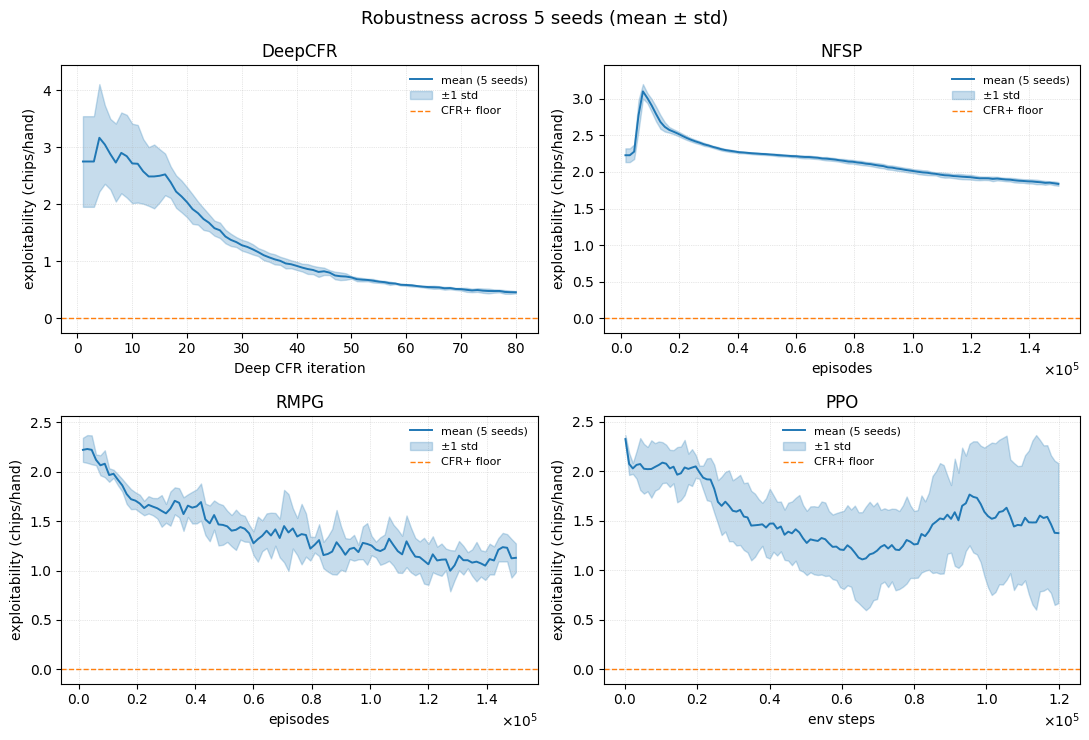

In [54]:
df_base = pd.read_csv(CONFIG.results_dir / "cfr_baseline.csv")

cfrp_floor = df_base[df_base["method"] == "CFR+"]["exploitability"].iloc[-1]
specs = [("DeepCFR", "iteration", "Deep CFR iteration", False),
         ("NFSP", "episodes", "episodes", True),
         (pg_label(CONFIG), "episodes", "episodes", True),
         ("PPO", "episodes", "env steps", True)]

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
for ax, (m, xcol, xlabel, dosci) in zip(axes.flat, specs):
    sub = robustness_df[robustness_df["method"] == m]
    grp = sub.groupby(xcol)["exploitability"]
    x, mean, std = grp.mean().index.values, grp.mean().values, grp.std().values
    ax.plot(x, mean, linewidth=1.4, color="C0", label="mean (5 seeds)")
    ax.fill_between(x, mean - std, mean + std, alpha=0.25, color="C0", label="±1 std")
    ax.axhline(cfrp_floor, linestyle="--", linewidth=1.0, color="C1", label="CFR+ floor")
    ymax = float((mean + std).max()); ax.set_ylim(-0.06 * ymax, ymax * 1.08)
    if dosci:
        ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0), useMathText=True)
    ax.set_xlabel(xlabel); ax.set_ylabel("exploitability (chips/hand)")
    ax.set_title(m); ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6)
    ax.legend(frameon=False, fontsize=8)
    
fig.suptitle("Robustness across 5 seeds (mean ± std)", fontsize=13)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(CONFIG.figures_dir / f"robustness_multiseed.{ext}", dpi=160)
plt.show()

### §9.2 Sensitivity sweep — NFSP anticipatory parameter η

η sets how often each NFSP agent acts from its **RL best response** (vs its average policy)
during a self-play episode. Too low and the best-response signal is weak; too high and the
reservoir fills with off-policy data and the average policy destabilizes. Heinrich & Silver
use η = 0.1. We sweep η ∈ {0.05, 0.1, 0.5} (a couple of seeds each, reduced budget) and plot
the exploitability bands — a compact view of how much this one knob moves the result.

In [55]:
def run_eta_sweep(cfg):
    '''Train NFSP at each anticipatory parameter eta over a few seeds; tag rows with eta.'''
    frames = []
    for eta in cfg.r9_sweep_etas:
        cfg_eta = replace(cfg, nfsp_anticipatory_param=eta)
        for seed in cfg.r9_sweep_seeds:
            env = rl_environment.Environment(cfg.game_name, players=2)
            df, _, _ = train_nfsp(env, cfg_eta, seed=seed)
            df = df.assign(eta=eta)
            frames.append(df)
        print(f"eta={eta} done")
    return pd.concat(frames, ignore_index=True)


sweep_df = run_eta_sweep(cfg9)
sweep_df.to_csv(CONFIG.results_dir / "robustness_nfsp_eta_sweep.csv", index=False)
print(f"wrote robustness_nfsp_eta_sweep.csv  ({len(sweep_df)} rows)")

eta=0.05 done


eta=0.1 done


eta=0.3 done


eta=0.5 done
wrote robustness_nfsp_eta_sweep.csv  (800 rows)


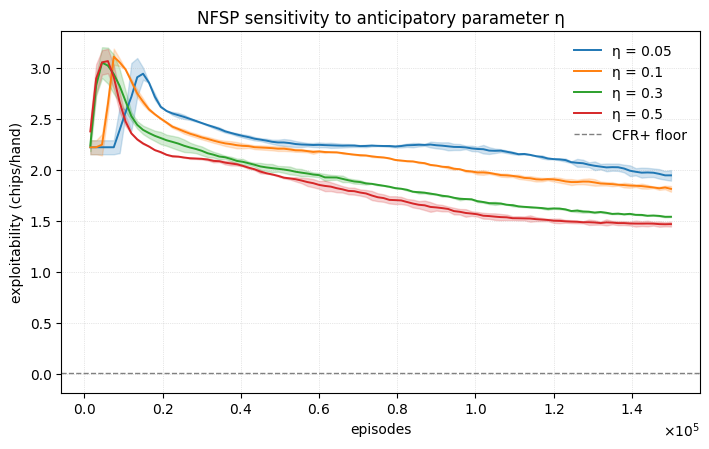

In [56]:
df_base = pd.read_csv(CONFIG.results_dir / "cfr_baseline.csv")
cfrp_floor = df_base[df_base["method"] == "CFR+"]["exploitability"].iloc[-1]

fig, ax = plt.subplots(figsize=(7.2, 4.6))
for i, eta in enumerate(CONFIG.r9_sweep_etas):
    sub = sweep_df[sweep_df["eta"] == eta]
    grp = sub.groupby("episodes")["exploitability"]
    x, mean, std = grp.mean().index.values, grp.mean().values, grp.std().values
    ax.plot(x, mean, linewidth=1.4, color=f"C{i}", label=f"η = {eta}")
    ax.fill_between(x, mean - std, mean + std, alpha=0.2, color=f"C{i}")
    
ax.axhline(cfrp_floor, linestyle="--", linewidth=1.0, color="gray", label="CFR+ floor")
ymax = float(sweep_df.groupby(["eta", "episodes"])["exploitability"].mean().max())
ax.set_ylim(-0.06 * ymax, ymax * 1.08)
ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0), useMathText=True)
ax.set_xlabel("episodes"); ax.set_ylabel("exploitability (chips/hand)")
ax.set_title("NFSP sensitivity to anticipatory parameter η")
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6); ax.legend(frameon=False)
fig.tight_layout()

for ext in ("pdf", "png"):
    fig.savefig(CONFIG.figures_dir / f"robustness_nfsp_eta_sweep.{ext}", dpi=160)
plt.show()

## §9.4 Mean reward versus fixed CFR opponents (Srinivasan-style)

Exploitability (§3-§6) and head-to-head (§7) both look at *final* policies. This section adds
the diagnostic from Srinivasan et al. (2018, Fig. 4): freeze a **CFR opponent** of a given
strength and watch each deep method's **mean reward against it climb over training**. It is an
intuitive, opponent-anchored view of "is the agent learning to play well?" that complements the
adversarial exploitability curve.

- **Opponents.** We run tabular CFR once and snapshot its average policy at
  {100, 500, 1000, 2000} iterations — four fixed opponents of increasing strength
  (CFR2000 is essentially the §2 equilibrium). CFR500 is the paper's reference.
- **Metric.** For the current policy of each method we compute the **exact seat-averaged
  expected reward** versus each CFR opponent (`head_to_head` from §7 = the exact tree
  expectation, no sampled games), so the curves are smooth rather than the paper's noisy
  rolling averages.
- **Methods.** Deep CFR, NFSP, RMPG, PPO. 3-player is omitted here because 3-player CFR is
  ~10 s/iteration (a CFR500 opponent alone would take >1 h).

**Expectation.** Mean reward should **rise from very negative toward 0 from below**: a learned
policy stops getting exploited by the CFR opponent (it cannot *beat* a near-equilibrium, so it
approaches the 0 line). Against the weaker CFR100 a good method may even go slightly positive.
PPO, the negative baseline, should stay lower / noisier — it never settles into a strategy that
holds its own against CFR.

In [57]:
# Train one tabular CFR run and snapshot its average policy at each milestone -> fixed
# opponents. tabular_from_policy (§7) materializes an independent copy at each snapshot so they
# don't alias the solver's evolving average. 2-player CFR is fast (seconds).
def train_cfr_opponents(game, snapshots, *, seed=0):
    set_global_seed(seed)
    solver = cfr.CFRSolver(game)
    want = set(snapshots)
    out = {}
    for it in tqdm(range(1, max(snapshots) + 1), desc="CFR opponents", leave=False):
        solver.evaluate_and_update_policy()
        if it in want:
            out[it] = tabular_from_policy(game, solver.average_policy())
    return out


cfr_snaps = train_cfr_opponents(game, CONFIG.mr_cfr_snapshots)
opponents = {f"CFR{it}": tab for it, tab in cfr_snaps.items()}
print("fixed CFR opponents (own exploitability — stronger = lower):")
for name, tab in opponents.items():
    print(f"  {name:8s} exploitability = {exploitability.exploitability(game, tab):.4f}")

fixed CFR opponents (own exploitability — stronger = lower):
  CFR100   exploitability = 0.0957
  CFR500   exploitability = 0.0215
  CFR1000  exploitability = 0.0118
  CFR2000  exploitability = 0.0068


In [58]:
# Reward-vs-opponent training drivers. They reuse the §3-§6 builders/wrappers and evaluate
# mean reward with head_to_head (§7) at _milestones (§8) checkpoints. Long-form rows:
# (method, seed, episodes, progress, opponent, mean_reward).
def _mr_selfplay(env, agents, joint, total_episodes, label, opponents, cfg, seed):
    rows, ep = [], 0
    pbar = tqdm(total=total_episodes, desc=f"mr-{label}", leave=False)
    for target in _milestones(total_episodes, cfg.mr_eval_points):
        while ep < target:
            ts = env.reset()
            while not ts.last():
                pid = ts.observations["current_player"]
                ts = env.step([agents[pid].step(ts).action])
            for a in agents:
                a.step(ts)
            ep += 1
            pbar.update(1)
        agent_tab = tabular_from_policy(env.game, joint)
        mr = {o: head_to_head(env.game, agent_tab, opp) for o, opp in opponents.items()}
        for o, v in mr.items():
            rows.append({"method": label, "seed": seed, "episodes": ep,
                         "progress": ep / total_episodes, "opponent": o, "mean_reward": v})
        if "CFR500" in mr:
            pbar.set_postfix(vsCFR500=f"{mr['CFR500']:.2f}")
    pbar.close()
    return pd.DataFrame(rows)


def mr_train_nfsp(env, cfg, opponents, *, seed=0):
    set_global_seed(seed)
    cfg_n = replace(cfg, nfsp_train_episodes=cfg.mr_nfsp_episodes)
    agents = make_nfsp_agents(env, cfg_n, seed=seed)
    joint = NFSPPolicies(env, agents, nfsp.MODE.AVERAGE_POLICY)
    return _mr_selfplay(env, agents, joint, cfg.mr_nfsp_episodes, "NFSP", opponents, cfg, seed)


def mr_train_pg(env, cfg, opponents, *, seed=0):
    set_global_seed(seed)
    agents = make_pg_agents(env, cfg, seed=seed)
    joint = PGPolicies(env, agents)
    return _mr_selfplay(env, agents, joint, cfg.mr_pg_episodes, pg_label(cfg), opponents, cfg, seed)


def mr_train_ppo(game, cfg, opponents, *, seed=0):
    set_global_seed(seed)
    learner = make_ppo_learner(game, cfg)
    penv = PPOSelfPlayEnv(game, learner)
    joint = PPOPolicies(game, learner)
    num_updates = cfg.mr_ppo_steps // cfg.ppo_steps_per_batch
    eval_at = set(_milestones(num_updates, cfg.mr_eval_points))
    rows = []
    time_step = [penv.reset()]
    pbar = tqdm(range(num_updates), desc="mr-PPO", leave=False)
    for update in pbar:
        for _ in range(cfg.ppo_steps_per_batch):
            out = learner.step(time_step)
            nts, r, d = penv.step(out[0].action)
            learner.post_step([r], [d])
            time_step = [nts]
        learner.learn(time_step)
        if (update + 1) in eval_at:
            agent_tab = tabular_from_policy(game, joint)
            mr = {o: head_to_head(game, agent_tab, opp) for o, opp in opponents.items()}
            for o, v in mr.items():
                rows.append({"method": "PPO", "seed": seed, "episodes": learner.total_steps_done,
                             "progress": (update + 1) / num_updates, "opponent": o, "mean_reward": v})
            if "CFR500" in mr:
                pbar.set_postfix(vsCFR500=f"{mr['CFR500']:.2f}")
    pbar.close()
    return pd.DataFrame(rows)


def mr_train_deepcfr(game, cfg, opponents, *, seed=0):
    set_global_seed(seed)
    chunk = max(1, cfg.mr_deepcfr_iterations // cfg.mr_eval_points)
    solver = deep_cfr.DeepCFRSolver(
        game, policy_network_layers=cfg.deepcfr_policy_layers,
        advantage_network_layers=cfg.deepcfr_advantage_layers, num_iterations=chunk,
        num_traversals=cfg.deepcfr_num_traversals, learning_rate=cfg.deepcfr_learning_rate,
        batch_size_advantage=cfg.deepcfr_batch_size, batch_size_strategy=cfg.deepcfr_batch_size,
        policy_network_train_steps=cfg.deepcfr_train_steps,
        advantage_network_train_steps=cfg.deepcfr_train_steps,
        memory_capacity=cfg.deepcfr_memory_capacity, reinitialize_advantage_networks=True,
        device=cfg.deepcfr_device, seed=seed)
    rows, it, total = [], 0, chunk * cfg.mr_eval_points
    for _ in tqdm(range(cfg.mr_eval_points), desc="mr-DeepCFR", leave=False):
        solver.solve()
        it += chunk
        agent_tab = deep_cfr_average_policy(game, solver)
        for o, opp in opponents.items():
            rows.append({"method": "DeepCFR", "seed": seed,
                         "episodes": it * game.num_players() * cfg.deepcfr_num_traversals,
                         "progress": it / total, "opponent": o,
                         "mean_reward": head_to_head(game, agent_tab, opp)})
    return pd.DataFrame(rows)

In [59]:
# Train each method once and log mean reward vs every CFR opponent over training (~10 min).
env_a = rl_environment.Environment(CONFIG.game_name, players=2)
df_mr_nfsp = mr_train_nfsp(env_a, CONFIG, opponents)
env_b = rl_environment.Environment(CONFIG.game_name, players=2)
df_mr_rmpg = mr_train_pg(env_b, CONFIG, opponents)
df_mr_ppo  = mr_train_ppo(game, CONFIG, opponents)
df_mr_deepcfr = mr_train_deepcfr(game, CONFIG, opponents)

df_mr = pd.concat([df_mr_deepcfr, df_mr_nfsp, df_mr_rmpg, df_mr_ppo], ignore_index=True)
df_mr.to_csv(CONFIG.results_dir / "mean_reward_vs_cfr.csv", index=False)
print(f"wrote mean_reward_vs_cfr.csv  ({len(df_mr)} rows)")
print("\nFinal mean reward vs each CFR opponent (chips/hand; -> 0 from below = matches it):")
print(df_mr.sort_values("progress").groupby(["method", "opponent"]).tail(1)
      .pivot(index="method", columns="opponent", values="mean_reward").round(3).to_string())

mr-RMPG:   0%|          | 0/1000000 [00:00<?, ?it/s]                                /Users/dk/Developer/Leduc/.venv/lib/python3.13/site-packages/open_spiel/python/pytorch/policy_gradient.py:425: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:312.)
  value_predictions = q_values[list(action_indices)]
                                                                                    

wrote mean_reward_vs_cfr.csv  (320 rows)

Final mean reward vs each CFR opponent (chips/hand; -> 0 from below = matches it):
opponent  CFR100  CFR1000  CFR2000  CFR500
method                                    
DeepCFR   -0.046   -0.082   -0.081  -0.081
NFSP      -0.205   -0.225   -0.222  -0.228
PPO       -0.364   -0.340   -0.329  -0.351
RMPG      -0.181   -0.185   -0.170  -0.187


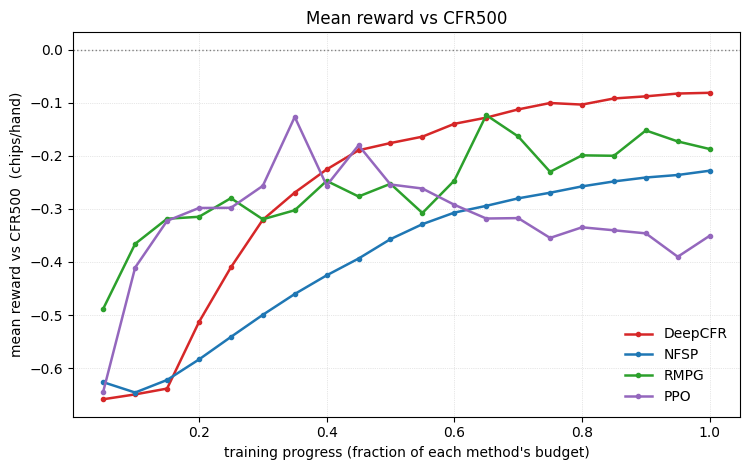

In [60]:
# Headline figure (paper's left panel): mean reward vs CFR500 for every method.
ORDER = ["DeepCFR", "NFSP", pg_label(CONFIG), "PPO"]
COLORS = {"DeepCFR": "C3", "NFSP": "C0", pg_label(CONFIG): "C2", "PPO": "C4"}

fig, ax = plt.subplots(figsize=(7.6, 4.8))
for m in ORDER:
    sub = df_mr[(df_mr["method"] == m) & (df_mr["opponent"] == "CFR500")].sort_values("progress")
    ax.plot(sub["progress"], sub["mean_reward"], marker="o", markersize=3, linewidth=1.8,
            label=m, color=COLORS[m])
ax.axhline(0.0, linestyle=":", linewidth=1.0, color="gray")
ax.set_xlabel("training progress (fraction of each method's budget)")
ax.set_ylabel("mean reward vs CFR500  (chips/hand)")
ax.set_title("Mean reward vs CFR500")
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6)
ax.legend(frameon=False)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(CONFIG.figures_dir / f"mean_reward_vs_cfr500.{ext}", dpi=160)
plt.show()

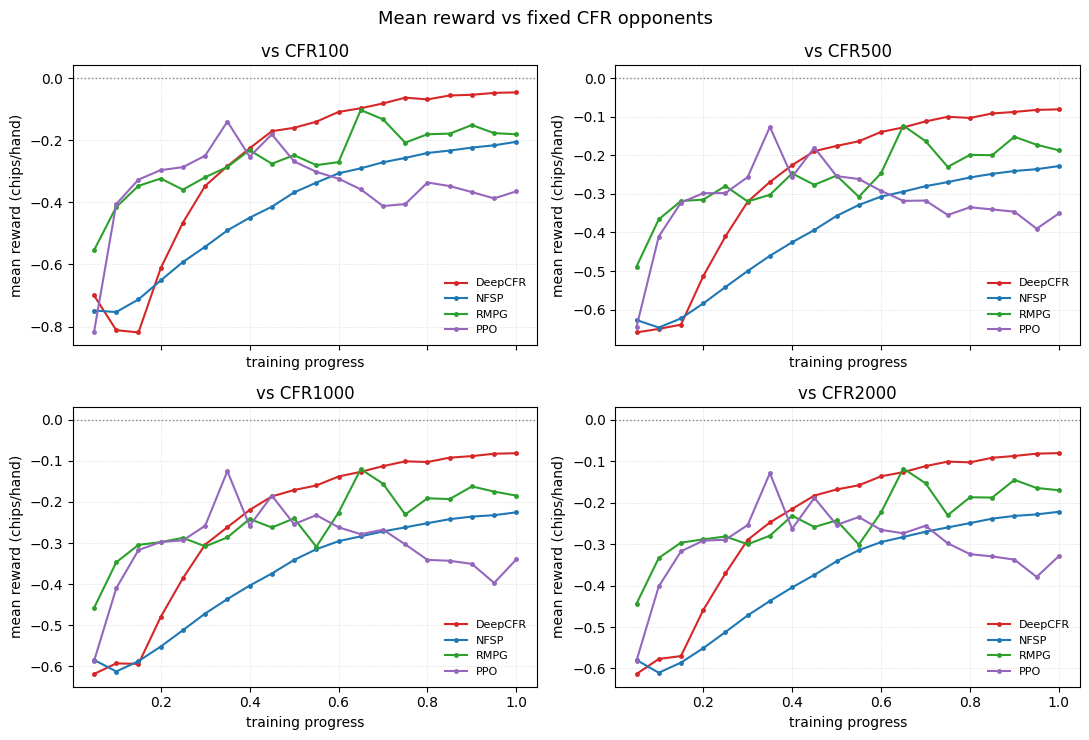

In [61]:
# Opponent-strength grid: one panel per CFR opponent, all methods overlaid. Shows how the
# reward ceiling drops toward 0 as the fixed opponent gets stronger.
opps = [f"CFR{k}" for k in CONFIG.mr_cfr_snapshots]
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True)
for ax, opp in zip(axes.flat, opps):
    for m in ORDER:
        sub = df_mr[(df_mr["method"] == m) & (df_mr["opponent"] == opp)].sort_values("progress")
        ax.plot(sub["progress"], sub["mean_reward"], marker="o", markersize=2.5, linewidth=1.5,
                label=m, color=COLORS[m])
    ax.axhline(0.0, linestyle=":", linewidth=1.0, color="gray")
    ax.set_title(f"vs {opp}")
    ax.set_xlabel("training progress"); ax.set_ylabel("mean reward (chips/hand)")
    ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6)
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("Mean reward vs fixed CFR opponents", fontsize=13)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(CONFIG.figures_dir / f"mean_reward_vs_cfr_grid.{ext}", dpi=160)
plt.show()

## §10 Aggregate and export

The closing section overlays every method on one axis — exploitability against **training
progress** — and confirms the deliverables. (Per-run wall-clock times are logged in every
CSV's `wall_clock_s` column for the RQ2 compute-efficiency discussion.) A manifest then
verifies that every figure is a vector PDF (LaTeX-ready) and every result a CSV. All cells
read the saved CSVs, so this section is fast and reproducible without retraining.

In [62]:
# Load every method's 2-player exploitability curve from its CSV (no retraining).
base = pd.read_csv(CONFIG.results_dir / "cfr_baseline.csv")
cfrp_floor = base[base["method"] == "CFR+"]["exploitability"].iloc[-1]
curves = {}
for lab in ("CFR", "CFR+"):
    s = base[base["method"] == lab].copy()
    s["progress"] = s["iteration"] / s["iteration"].max()
    curves[lab] = s
for name, csv, xc in [("DeepCFR", "deep_cfr.csv", "iteration"),
                      ("NFSP", "nfsp.csv", "episodes"),
                      (pg_label(CONFIG), f"{pg_label(CONFIG).lower()}.csv", "episodes"),
                      ("PPO", "ppo.csv", "episodes")]:
    s = pd.read_csv(CONFIG.results_dir / csv)
    s["progress"] = s[xc] / s[xc].max()
    curves[name] = s
COL = {"CFR": "C5", "CFR+": "C1", "DeepCFR": "C3", "NFSP": "C0", pg_label(CONFIG): "C2", "PPO": "C4"}
print("loaded curves:", list(curves))

loaded curves: ['CFR', 'CFR+', 'DeepCFR', 'NFSP', 'RMPG', 'PPO']


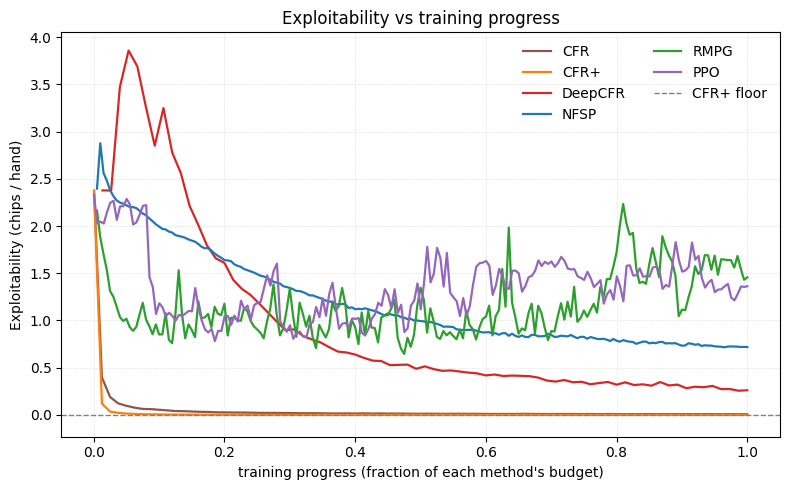

In [63]:
# Combined: exploitability vs training progress (all methods on one axis).
fig, ax = plt.subplots(figsize=(8, 5))
for m, s in curves.items():
    ax.plot(s["progress"], s["exploitability"], label=m, color=COL.get(m), linewidth=1.6)
ax.axhline(cfrp_floor, linestyle="--", linewidth=1.0, color="gray", label="CFR+ floor")
ymax = max(cs["exploitability"].max() for cs in curves.values())
ax.set_ylim(-0.06 * ymax, ymax * 1.05)
ax.set_xlabel("training progress (fraction of each method's budget)")
ax.set_ylabel("Exploitability (chips / hand)")
ax.set_title("Exploitability vs training progress")
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(CONFIG.figures_dir / f"aggregate_exploitability.{ext}", dpi=160)
plt.show()

In [64]:
# Deliverables manifest: vector PDF for every figure, CSV for every result, checkpoint per model.
figs = sorted(CONFIG.figures_dir.glob("*.pdf"))
csvs = sorted(CONFIG.results_dir.glob("*.csv"))
ckpts = sorted(p for p in CONFIG.checkpoints_dir.glob("*") if p.is_file())
print(f"FIGURES — {len(figs)} (each also has a .png preview):")
for p in figs: print("  ", p.stem)
print(f"\nRESULTS — {len(csvs)} CSV:")
for p in csvs: print("  ", p.name)
print(f"\nCHECKPOINTS — {len(ckpts)}:")
for p in ckpts: print("  ", p.name)
print("\nAll figures are vector PDF (LaTeX-ready) + PNG preview; all numeric results are CSV.")

FIGURES — 15 (each also has a .png preview):
   aggregate_exploitability
   cfr_baseline
   deep_cfr
   head_to_head
   mean_reward_vs_cfr500
   mean_reward_vs_cfr_grid
   nfsp
   nfsp_eta_behaviour
   ppo
   rmpg
   rmpg_entropy_experiment
   robustness_multiseed
   robustness_nfsp_eta_sweep
   strategy_fingerprint
   three_player_nashconv

RESULTS — 14 CSV:
   cfr_baseline.csv
   deep_cfr.csv
   head_to_head_chips.csv
   head_to_head_mbbg.csv
   mean_reward_vs_cfr.csv
   nfsp.csv
   nfsp_eta_behaviour.csv
   ppo.csv
   rmpg.csv
   rmpg_entropy_experiment.csv
   robustness_multiseed.csv
   robustness_nfsp_eta_sweep.csv
   strategy_style_summary.csv
   three_player_nashconv.csv

CHECKPOINTS — 6:
   cfr_avg_policy.pkl
   cfr_plus_avg_policy.pkl
   deep_cfr.pt
   nfsp.pt
   ppo.pt
   rmpg.pt

All figures are vector PDF (LaTeX-ready) + PNG preview; all numeric results are CSV.
